betül danışmaz


## Step 1: Load Data and Initial Inspection

This step involves loading the provided `train.csv`, `test_x.csv`, and `sample_submission.csv` files into pandas DataFrames, followed by an initial inspection of their shapes, column names, data types, and first few rows.

### Step 1.1: Kaggle Login

This cell logs into Kaggle using the Kaggle API. This is necessary to download competition data directly within the Colab environment.

**Output to inspect:** Confirmation that Kaggle credentials have been successfully validated.

In [ ]:
# HÜCRE A1
# Step 1.1: Kaggle Login
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


### Step 1.2: Download Competition Data

This cell downloads the specified competition data from Kaggle. The `kagglehub.competition_download` function retrieves the data, and its path is stored.

**Output to inspect:** A message confirming that the data source import is complete.

In [ ]:
# HÜCRE A2
# Step 1.2: Download Competition Data
yzta_2026_datathon_path = kagglehub.competition_download('yzta-2026-datathon')
print('Data source import complete.')

100%|██████████| 7.11M/7.11M [00:00<00:00, 30.8MB/s]

Extracting files...


Data source import complete.


### Step 1.3: File Organization

This cell organizes the downloaded files. It creates a dedicated directory and copies the downloaded CSV files into it, making them easily accessible for loading into pandas DataFrames.

**Output to inspect:** No direct output, but successful execution means files are correctly structured.

In [ ]:
# HÜCRE A3

# Step 1.3: File Organization
import os
import shutil
dest_dir = '/content/yzta-2026-datathon'
os.makedirs(dest_dir, exist_ok=True)
for file in os.listdir(yzta_2026_datathon_path):
    shutil.copy(os.path.join(yzta_2026_datathon_path, file), dest_dir)
yzta_2026_datathon_path = dest_dir

### Step 1.4: Verify Data Files

This cell lists the contents of the data directory to confirm that `train.csv`, `test_x.csv`, and `sample_submission.csv` are present.

**Output to inspect:** A list of files in the `data_path` directory, which should include the three required CSVs.

In [ ]:
# HÜCRE A4

import os

data_path = "/content/yzta-2026-datathon"

print(os.listdir(data_path))


['train.csv', 'test_x.csv', 'sample_submission.csv']


### Step 1.5: Load DataFrames

This cell loads the `train.csv`, `test_x.csv`, and `sample_submission.csv` files into pandas DataFrames named `train`, `test`, and `sample_submission`, respectively. These DataFrames will be used for all subsequent analysis and modeling.

**Output to inspect:** No direct output from this cell, but successful loading is implied if the next cells execute without file not found errors.

In [ ]:
# HÜCRE A5

# Step 1.4: Load DataFrames
import pandas as pd
import numpy as np
train = pd.read_csv(os.path.join(data_path, 'train.csv'))
test = pd.read_csv(os.path.join(data_path, 'test_x.csv'))
sample_submission = pd.read_csv(os.path.join(data_path, 'sample_submission.csv'))

### Step 1.6: Inspect Data Shapes and Head

This cell prints the dimensions (number of rows and columns) of each DataFrame and displays the first 5 rows using `df.head()`. This gives a quick overview of the data size and content.

**Output to inspect:** The shape of each DataFrame and the first few rows, ensuring data loaded correctly.

In [ ]:
# HÜCRE A6

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())
display(test.head())
display(sample_submission.head())

Train shape: (56000, 24)
Test shape: (24000, 23)
Sample submission shape: (2, 2)


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi
0,1,42,Erkek,Saglik Personeli,29.728724,Ingiltere,21.691917,23.990157,21,5,...,0,6.349196,9.419561,Gece insani,Depresyon,82,21.627129,1.716161,Ilkbahar-Yaz,Hafta sonu
1,2,26,Kadin,Serbest Calisan,32.865996,Cin,22.090624,18.231963,34,5,...,0,NaN,8.574199,Gece insani,Saglikli,66,27.835934,1.482283,Ilkbahar-Yaz,Hafta ici
2,3,21,Erkek,Lojistik Calisani,24.438264,Cin,19.488438,16.695363,17,4,...,52,6.715192,10.519017,Notr,Depresyon,63,20.252258,1.981034,Sonbahar-Kis,Hafta ici
3,4,61,Kadin,Saglik Personeli,23.275057,Cin,26.831092,21.762040,29,2,...,2,5.633400,9.814789,Gece insani,Saglikli,71,17.680971,0.589750,Sonbahar-Kis,Hafta ici
4,5,26,Kadin,Saglik Personeli,24.815531,Ingiltere,16.271522,18.153212,15,4,...,0,7.953794,9.308398,Sabah insani,Saglikli,53,23.698979,0.622211,Ilkbahar-Yaz,Hafta ici


,id,bilissel_performans_skoru
0,1,7.85
1,2,4.32


### Step 1.7: Inspect Column Names

This cell prints the list of column names for `train`, `test`, and `sample_submission`. This is crucial for verifying that all expected features are present and correctly named.

**Output to inspect:** Lists of column names for each DataFrame.

In [ ]:
# HÜCRE A7

print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nSubmission columns:")
print(sample_submission.columns.tolist())

Train columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi', 'bilissel_performans_skoru']

Test columns:
['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke', 'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati', 'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm', 'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim', 'gun_tipi']

Submission columns:
['id', 'bilissel_performans_skoru']


### Step 1.8: Verify Target and ID Handling

This cell explicitly checks the presence of the `target` variable (`bilissel_performans_skoru`) and the `id` column in the `train`, `test`, and `sample_submission` DataFrames. This step ensures that the target is only in the training set and that `id` is available for submission.

**Output to inspect:** Boolean values indicating the presence of `target` and `id` in each DataFrame. Ensure `Target in train` is `True`, `Target in test` is `False`, and `ID` is `True` in all.

In [ ]:
# HÜCRE A8

target = "bilissel_performans_skoru"
id_col = "id"

print("Target in train:", target in train.columns)
print("Target in test:", target in test.columns)
print("ID in train:", id_col in train.columns)
print("ID in test:", id_col in test.columns)
print("ID in sample_submission:", id_col in sample_submission.columns)
print("Target in sample_submission:", target in sample_submission.columns)

Target in train: True
Target in test: False
ID in train: True
ID in test: True
ID in sample_submission: True
Target in sample_submission: True


### Step 1.9: Inspect Training Data Information (`train.info()`)

This cell provides a concise summary of the `train` DataFrame, including the column names, non-null counts, data types, and memory usage. This helps identify missing values and incorrect data types early on.

**Output to inspect:** Column information, especially the `Non-Null Count` to spot missing values and `Dtype` to confirm correct data type inference.

In [ ]:
# HÜCRE A9


train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi

### Step 1.10: Inspect Test Data Information (`test.info()`)

Similar to the training data, this cell provides a concise summary of the `test` DataFrame. It's essential to compare this with `train.info()` to note any discrepancies in column types or missing value patterns between the train and test sets.

**Output to inspect:** Column information for the test set, paying attention to `Non-Null Count` and `Dtype`.

In [ ]:
# HÜCRE A10



test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           24000 non-null  int64  
 1   yas                          24000 non-null  int64  
 2   cinsiyet                     24000 non-null  object 
 3   meslek                       23378 non-null  object 
 4   vucut_kitle_indeksi          23352 non-null  float64
 5   ulke                         24000 non-null  object 
 6   rem_yuzdesi                  24000 non-null  float64
 7   derin_uyku_yuzdesi           24000 non-null  float64
 8   uykuya_dalma_suresi_dk       24000 non-null  int64  
 9   gecelik_uyanma_sayisi        24000 non-null  int64  
 10  uyku_oncesi_kafein_mg        23303 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  24000 non-null  int64  
 12  gunluk_adim_sayisi           24000 non-null  int64  
 13  sekerleme_suresi

### Step 1.11: Analyze Target Variable Summary Statistics

This cell calculates and displays descriptive statistics for the target variable (`bilissel_performans_skoru`) in the training set. This includes count, mean, standard deviation, min, max, and quartiles.

**Output to inspect:** The summary statistics to understand the range, central tendency, and spread of the target variable.

In [ ]:
# HÜCRE A12


train[target].describe()

,bilissel_performans_skoru
count,56000.000000
mean,5.913096
std,2.231759
min,0.000000
25%,4.397431
50%,6.032249
75%,7.574980
max,10.000000


### Step 1.12: Visualize Target Distribution

This cell generates a histogram of the target variable to visually assess its distribution. Understanding the target distribution is crucial for choosing appropriate evaluation metrics and modeling techniques.

**Output to inspect:** The histogram of the target variable. Look for normality, skewness, or potential outliers.

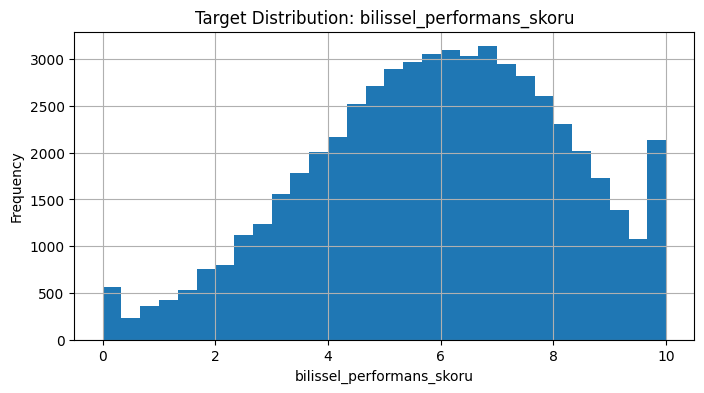

In [ ]:
# HÜCRE A13


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
train[target].hist(bins=30)
plt.title("Target Distribution: bilissel_performans_skoru")
plt.xlabel("bilissel_performans_skoru")
plt.ylabel("Frequency")
plt.show()

## Step 2: Feature Engineering and Preparation

This step involves separating features and target, identifying feature types, and defining a function for domain-specific feature engineering. It also includes checks for consistency between train and test feature columns.

### Step 2.1: Initial X/Y Separation

This cell separates the training data (`train`) into features (`X`) and the target variable (`y`). It also identifies the `id` column, ensuring it's excluded from the feature set as per project rules.

**Output to inspect:** No explicit output, but `X` and `y` DataFrames are created, ready for further processing.

In [ ]:
# HÜCRE A14


# Step 2.1: Initial X/Y Separation
target = 'bilissel_performans_skoru'
id_col = 'id'
feature_cols = [col for col in train.columns if col not in [target, id_col]]
X = train[feature_cols]
y = train[target]

### Step 2.2: Feature Type Identification

This cell automatically identifies numerical and categorical features within the `X` DataFrame based on their data types. This classification is important for applying appropriate preprocessing steps.

**Output to inspect:** No explicit output, but two lists (`numeric_features` and `categorical_features`) are created containing the names of columns of each type.

In [ ]:
# HÜCRE A15


# Step 2.2: Feature Type Identification
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

### Step 2.3: Domain-Specific Feature Engineering Function

This cell defines a helper function `add_domain_features` that creates new features based on existing ones, particularly focusing on sleep-related metrics. This allows for modular and consistent application of domain knowledge.

**Output to inspect:** No output, just the definition of the function.

In [ ]:
# HÜCRE A16

def add_domain_features(df, group='all'):
    df_new = df.copy()

    # Existing Sleep Features
    if group in ['sleep', 'all']:
        df_new['total_quality_sleep_pct'] = df_new['rem_yuzdesi'] + df_new['derin_uyku_yuzdesi']
        df_new['sleep_fragmentation_idx'] = df_new['gecelik_uyanma_sayisi'] + (df_new['uykuya_dalma_suresi_dk'] / 30.0)

    # Experiment C: Fatigue / Behavior Features
    if group in ['fatigue_behavior', 'all']:
        df_new['pre_sleep_load'] = (
            df_new['uyku_oncesi_kafein_mg'].fillna(0) / 100
            + df_new['uyku_oncesi_ekran_suresi_dk'] / 60
        )
        df_new['stress_workload'] = (
            df_new['stres_skoru'].fillna(df_new['stres_skoru'].median()) * df_new['gunluk_calisma_saati']
        )
        df_new['activity_per_work_hour'] = (
            df_new['gunluk_adim_sayisi'] / (df_new['gunluk_calisma_saati'] + 1)
        )
        df_new['hr_stress'] = (
            df_new['dinlenik_nabiz_bpm'] * df_new['stres_skoru'].fillna(df_new['stres_skoru'].median())
        )

    return df_new

### Step 2.4: Compare Train/Test Feature Columns

This cell compares the feature columns between the training and test sets to ensure consistency. It identifies any columns present in one set but not the other, which is crucial for preventing errors during model training and prediction.

**Output to inspect:** Any missing or extra feature columns in the test set. Ideally, both lists (`missing_in_test`, `extra_in_test`) should be empty.

In [ ]:
# HÜCRE A17

# Check whether train and test have the same feature columns
missing_in_test = set(feature_cols) - set(test.columns)
extra_in_test = set(test.columns) - set(feature_cols) - {id_col}

print("Missing feature columns in test:", missing_in_test)
print("Extra columns in test:", extra_in_test)

Missing feature columns in test: set()
Extra columns in test: set()


### Step 2.5: Check Missing Values in Features

This cell calculates and displays the count of missing values for each feature in both the `train` and `test` DataFrames. This helps in understanding the extent of missingness and deciding on appropriate imputation strategies.

**Output to inspect:** A sorted list of columns and their missing value counts for both train and test sets. Note which columns have missing data and how many.

In [ ]:
# HÜCRE A18

print("Missing values in train:")
display(train[feature_cols].isnull().sum().sort_values(ascending=False))

print("\nMissing values in test:")
display(test[feature_cols].isnull().sum().sort_values(ascending=False))

Missing values in train:


,0
kronotip,1968
vucut_kitle_indeksi,1752
stres_skoru,1715
uyku_oncesi_kafein_mg,1463
meslek,1378
ruh_sagligi_durumu,1096
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0



Missing values in test:


,0
kronotip,832
stres_skoru,765
uyku_oncesi_kafein_mg,697
vucut_kitle_indeksi,648
meslek,622
ruh_sagligi_durumu,504
rem_yuzdesi,0
ulke,0
yas,0
cinsiyet,0


### Step 2.6: Analyze Categorical Cardinality

This cell calculates and displays the number of unique values (cardinality) for each categorical feature in the training set. It also shows the top 5 frequency counts for high-cardinality features. This informs decisions on encoding strategies.

**Output to inspect:** The cardinality of each categorical feature and the frequency distribution for selected high-cardinality features. This helps assess if features like `ulke` or `meslek` require special handling like target encoding.

In [ ]:
# HÜCRE A19

print("Categorical Cardinality (Unique Values):")
cardinality = train[categorical_features].nunique().sort_values(ascending=False)
display(cardinality)

print("\nTop 5 category frequencies for high-cardinality features:")
for col in cardinality.index[:3]: # Check the top 3 most diverse columns
    print(f"\n--- {col} ---")
    display(train[col].value_counts(normalize=True).head(5))

# Best course of action:
# 1. Use One-Hot Encoding for all categories as the total number of features remains manageable.
# 2. Set handle_unknown='ignore' to robustly manage unseen categories in the test set.
# 3. If cardinality for 'ulke' or 'meslek' is extremely high (>50), consider Target Encoding in later iterations.

Categorical Cardinality (Unique Values):


,0
ulke,15
meslek,11
ruh_sagligi_durumu,4
kronotip,3
cinsiyet,2
mevsim,2
gun_tipi,2



Top 5 category frequencies for high-cardinality features:

--- ulke ---


,proportion
ulke,
Ingiltere,0.202214
Cin,0.178375
Guney Kore,0.079625
Amerika,0.079411
Arjantin,0.070946



--- meslek ---


,proportion
meslek,
Saglik Personeli,0.180184
Ogrenci,0.148878
Muhendis,0.119604
Yonetici,0.081542
Egitimci,0.080462



--- ruh_sagligi_durumu ---


,proportion
ruh_sagligi_durumu,
Saglikli,0.698765
Anksiyete,0.150627
Depresyon,0.100248
Anksiyete ve depresyon,0.050361


## Step 3: Initial Model Setup and Baseline Experiment

This section sets up the modeling environment by installing necessary libraries, defining evaluation metrics, and establishing a baseline CatBoost model with initial parameters.

### Step 3.1: Install Dependencies

This cell installs `lightgbm` and `catboost` libraries silently. These libraries are popular for gradient boosting models and will be used for modeling in this project.

**Output to inspect:** No explicit output if successful, but a log showing installation if there are issues.

In [ ]:
# HÜCRE A20

# Step 3.1: Install Dependencies
!pip install lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


### Step 3.2: Evaluation Metrics Definition

This cell defines a function `evaluate_predictions` that calculates the Root Mean Squared Error (RMSE) for model predictions. It also clips predictions between 0 and 10, as the target variable is known to be in this range. RMSE is a common metric for regression problems.

**Output to inspect:** No output from this cell, just the function definition.

In [ ]:
# HÜCRE A21
# Step 3.2: Evaluation Metrics Definition
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_predictions(y_true, preds, model_name='model'):
    preds = np.clip(preds, 0, 10)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    print(f'{model_name} RMSE: {rmse:.5f}')
    return rmse

### Step 3.3: Prepare Categorical Data (X_cat)

This cell prepares categorical features for CatBoost. It creates a copy of `X`, fills any missing categorical values with 'Missing', and converts them to string type. It also identifies the indices of these categorical features for CatBoost's native handling.

**Output to inspect:** No direct output, but `X_cat` is prepared and `cat_feature_indices` are created.

In [ ]:
# HÜCRE A22
# Step 4.1: Prepare Categorical Data (X_cat)
from sklearn.model_selection import KFold
X_cat = X.copy()
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna('Missing').astype(str)
cat_feature_indices = [X_cat.columns.get_loc(col) for col in categorical_features]

### Step 3.4: Core CV Evaluation Function

This cell defines `evaluate_catboost_cv`, a critical function for performing K-Fold cross-validation with CatBoost. It trains and evaluates a CatBoost model across multiple folds, reporting the RMSE for each fold and allowing early stopping to prevent overfitting.

**Output to inspect:** No output from this cell, just the function definition. This function will be called repeatedly in subsequent experiments.

In [ ]:
# HÜCRE A23
# Step 4.2: Core CV Evaluation Function
from catboost import CatBoostRegressor
def evaluate_catboost_cv(params, X_data, y_data, cat_features, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr, X_val = X_data.iloc[train_idx], X_data.iloc[valid_idx]
        y_tr, y_val = y_data.iloc[train_idx], y_data.iloc[valid_idx]
        model = CatBoostRegressor(loss_function='RMSE', eval_metric='RMSE', random_seed=42, verbose=0, **params)
        model.fit(X_tr, y_tr, cat_features=cat_features, eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100)
        preds = np.clip(model.predict(X_val), 0, 10)
        fold_results.append({'fold': fold, 'RMSE': np.sqrt(mean_squared_error(y_val, preds)), 'best_iteration': model.get_best_iteration()})
    return pd.DataFrame(fold_results)

### Step 3.5: 5-Fold CV Baseline: Optimized CatBoost

This cell establishes a baseline performance for the CatBoost model using a predefined set of hyperparameters and 5-fold cross-validation. This baseline will be used to compare the effectiveness of various feature engineering and hyperparameter tuning experiments.

**Output to inspect:** A DataFrame showing the RMSE for each fold and a message indicating the start of the CV process. This provides the initial benchmark RMSE.

### 5-Fold CV Baseline: Optimized CatBoost
Establishing the benchmark performance with selected hyperparameters.

In [ ]:
# HÜCRE A24
final_baseline_params = {
    'iterations': 2000,
    'learning_rate': 0.015,
    'depth': 6,
    'l2_leaf_reg': 8
}

print("Starting 5-Fold Cross-Validation for Baseline...")
baseline_cv_results = evaluate_catboost_cv(
    params=final_baseline_params,
    X_data=X_cat,
    y_data=y,
    cat_features=cat_feature_indices,
    n_splits=5
)

display(baseline_cv_results)

Starting 5-Fold Cross-Validation for Baseline...


KeyboardInterrupt: 

## Step 4: Experiment 2.1: Missing Indicators

This experiment investigates whether adding binary indicator features for missing values improves model performance. It compares the mean CV RMSE with and without these indicators against the established baseline.

### Step 4.1: Adding Missing Indicator Columns

This cell creates binary indicator columns for features that originally had missing values in the raw training set. These new columns will be `1` if the value was missing and `0` otherwise, allowing the model to explicitly learn from missingness patterns.

**Output to inspect:** A message confirming the number of added indicator columns, followed by a comparison of the mean RMSE between the baseline and the indicator experiment. Observe if the RMSE improves.

### Experiment 2.1: Missing Indicators
Adding binary flags to capture whether data was originally missing before imputation.

In [ ]:
# HÜCRE A25
X_cat_indicators = X_cat.copy()

# Identify columns that originally had missing values in the raw training set
missing_cols = train.columns[train.isnull().any()].tolist()
# Exclude target if it's in the list (it shouldn't be, but for safety)
missing_cols = [c for c in missing_cols if c in X_cat_indicators.columns]

for col in missing_cols:
    X_cat_indicators[f"{col}_is_missing"] = train[col].isnull().astype(int)

# Update categorical indices if any new categorical columns were added (none here, as they are int)
print(f"Added {len(missing_cols)} indicator columns.")

# Run CV with indicators
indicator_cv_results = evaluate_catboost_cv(
    params=final_baseline_params,
    X_data=X_cat_indicators,
    y_data=y,
    cat_features=cat_feature_indices,
    n_splits=5
)

print("\nComparison to Baseline:")
print(f"Baseline Mean RMSE: {baseline_cv_results['RMSE'].mean():.5f}")
print(f"Indicator Mean RMSE: {indicator_cv_results['RMSE'].mean():.5f}")

## Step 5: Feature Engineering Experiments Continued

This section continues with advanced feature engineering techniques, including Iterative Imputer, KNN Imputation, and Blended Imputation, followed by outlier handling and enhanced categorical feature encoding methods like Frequency Encoding and Smoothed Target Encoding.

### Step 5.1: Standardizing CatBoost Categorical Handling

This cell ensures that all categorical features in `X_cat` are consistently prepared for CatBoost's native handling. It fills any remaining NaNs in categorical columns with a uniform `__MISSING__` string and re-verifies the categorical feature indices.

**Output to inspect:** Confirmation of categorical columns prepared, their indices, and a check that no NaNs remain in these columns. This ensures consistent input for CatBoost.

### Experiment 2.2: IterativeImputer (MICE)
Testing if predicting missing numeric values based on other features improves performance.

### Experiment 2.3: KNN Imputation
Using the 5 nearest neighbors to estimate missing values, with internal scaling to ensure distance metrics are valid.

### Experiment 2.4: Blended Imputation (MICE + KNN)
Creating a hybrid imputation by averaging the predictions of IterativeImputer and KNNImputer to reduce bias from any single method.

### Step 3: Outlier Handling Strategy
Testing if capping numeric features at IQR-based boundaries reduces noise and improves RMSE.

### Step 4.1: CatBoost Native Categorical Handling
Standardizing the categorical feature preparation by using explicit string casting and a uniform missing value token.

In [ ]:
# HÜCRE A26
# Standardizing X_cat for the remainder of the project
for col in categorical_features:
    X_cat[col] = X_cat[col].fillna("__MISSING__").astype(str)

# Re-verify indices to be absolutely sure
cat_feature_indices = [X_cat.columns.get_loc(col) for col in categorical_features]

print(f"Categorical columns prepared: {categorical_features}")
print(f"Indices: {cat_feature_indices}")

# Brief check to ensure no actual NaNs remain in categorical data
print("Remaining NaNs in X_cat categorical columns:", X_cat[categorical_features].isnull().sum().sum())

Categorical columns prepared: ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']
Indices: [1, 2, 4, 15, 16, 20, 21]
Remaining NaNs in X_cat categorical columns: 0


### Step 5.2: Evaluate CatBoost with Frequency Encoding

This cell defines a function to evaluate CatBoost models that incorporate frequency encoding. Frequency encoding replaces categorical values with their observed frequencies in the training data, applied within each CV fold to prevent data leakage. It then runs the experiment with selected columns.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE for the frequency encoding experiment. Compare this to previous RMSEs to see if it provides a benefit.

### Experiment 4.2: Frequency Encoding
Adding numeric features representing the relative frequency of categories in the training fold.

In [ ]:
# HÜCRE A27
def evaluate_catboost_with_freq_encoding(params, X_data, y_data, cat_features, freq_cols, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    # Convert cat_features (indices) back to names for easier mapping
    cat_col_names = [X_data.columns[i] for i in cat_features]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # Apply Frequency Encoding per fold
        for col in freq_cols:
            freq_map = X_tr[col].value_counts(normalize=True).to_dict()
            X_tr[f"{col}_freq"] = X_tr[col].map(freq_map)
            X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)

        # Identify new cat indices because we added numeric columns
        current_cat_indices = [X_tr.columns.get_loc(c) for c in cat_col_names]

        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr, cat_features=current_cat_indices,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nFreq Encoding Mean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

# Define columns to freq-encode
freq_target_cols = ['meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu']

# Run the experiment
freq_cv_results = evaluate_catboost_with_freq_encoding(
    params=final_baseline_params,
    X_data=X_cat,
    y_data=y,
    cat_features=cat_feature_indices,
    freq_cols=freq_target_cols
)

### Step 5.3: Evaluate CatBoost with Smoothed Target Encoding

This cell defines a function for smoothed target encoding within CatBoost's cross-validation framework. Target encoding replaces categorical values with the mean of the target variable for that category, with smoothing applied to prevent overfitting to rare categories. This is applied in a fold-safe manner to prevent leakage.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE for the target encoding experiments (high cardinality and all categories). Look for improvements over previous methods.

### Experiment 5: Smoothed Target Encoding
Testing if mapping categories to the mean target value improves performance, using smoothing to handle low-frequency categories and strictly preventing fold leakage.

In [ ]:
# HÜCRE A28
def evaluate_catboost_with_target_encoding(params, X_data, y_data, cat_features, te_cols, smoothing=10, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    cat_col_names = [X_data.columns[i] for i in cat_features]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        global_mean = y_tr.mean()

        for col in te_cols:
            # Calculate smoothed mean for each category
            agg = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
            counts = agg['count']
            means = agg['mean']

            # formula: (count * mean + smoothing * global_mean) / (count + smoothing)
            smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)

            X_tr[f"{col}_te"] = X_tr[col].map(smooth).fillna(global_mean)
            X_val[f"{col}_te"] = X_val[col].map(smooth).fillna(global_mean)

        current_cat_indices = [X_tr.columns.get_loc(c) for c in cat_col_names]

        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr, cat_features=current_cat_indices,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nTarget Encoding ({te_cols}) Mean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

# Run Exp 5B: High Cardinality Only
te_high_cols = ['meslek', 'ulke']
print("Evaluating Experiment 5B (High Cardinality TE)...")
te_5b_results = evaluate_catboost_with_target_encoding(final_baseline_params, X_cat, y, cat_feature_indices, te_high_cols)

# Run Exp 5C: All Categories
print("\nEvaluating Experiment 5C (All Categories TE)...")
te_5c_results = evaluate_catboost_with_target_encoding(final_baseline_params, X_cat, y, cat_feature_indices, categorical_features)

## Step 6: Champion Pipeline Analysis

This section explicitly defines and verifies the current 'champion' pipeline based on the best performing experiments so far. This pipeline will serve as the baseline for further combinatorial feature engineering experiments.

### Step 6.1: Display Champion Pipeline Performance

This cell prints and displays the mean CV RMSE of the current champion pipeline, which has been identified as 'Target Encoding All Categories'. This provides a clear reference point for subsequent experiments.

**Output to inspect:** The mean CV RMSE and the full results DataFrame for the champion pipeline.

In [ ]:
# HÜCRE A29
print("--- Champion Pipeline Performance ---")
print(f"Champion (Target Encoding All Categories) Mean CV RMSE: {te_5c_results['RMSE'].mean():.5f}")
display(te_5c_results)

## Step 7: Test Combined Feature Sets

This section systematically evaluates combinations of feature engineering techniques, building upon the current champion pipeline. The goal is to determine if combining sleep-related features, frequency encoding, and target encoding yields further improvements in RMSE.

### Step 7.1: Reconfirm Current Champion Baseline

This cell simply reiterates the performance of the current champion pipeline (CatBoost with all-category target encoding). This serves as the direct baseline for comparison in the upcoming combined feature set experiments.

**Output to inspect:** The mean CV RMSE and results for the champion pipeline, confirming the baseline.

#### Experiment 3.1: TE all categories (Current Champion Baseline)

This is the current champion pipeline with CatBoost native handling and fold-safe target encoding for all categorical features. Its performance serves as the baseline for this section.

In [ ]:
# HÜCRE A30
print(f"Current Champion (TE all categories) Mean CV RMSE: {te_5c_results['RMSE'].mean():.5f}")
display(te_5c_results)

### Step 7.2: Define General Feature Engineering Evaluation Function

This cell defines a flexible function, `evaluate_catboost_with_feature_engineering`, to apply various feature engineering steps (target encoding, frequency encoding, etc.) within each cross-validation fold. This ensures proper fold-safety and avoids code repetition for combined experiments.

**Output to inspect:** No output from this cell, just the function definition. This function will be used for all subsequent combined feature set experiments.

#### Define General Feature Engineering Evaluation Function

To avoid code repetition and ensure proper fold-safe application of various feature engineering steps (like target encoding and frequency encoding), we will define a general evaluation function. This function will apply the specified transformations *within each cross-validation fold*.

In [ ]:
# HÜCRE B1
def evaluate_catboost_with_feature_engineering(params, X_data, y_data, cat_features_for_catboost, te_cols=None, freq_cols=None, smoothing=10, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []

    # CatBoost native categorical features are passed as indices. Convert to names for FE operations.
    cat_col_names = [X_data.columns[i] for i in cat_features_for_catboost]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # Apply Target Encoding if specified
        if te_cols:
            global_mean = y_tr.mean()
            for col in te_cols:
                # Calculate smoothed mean for each category based on training fold
                agg = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
                counts = agg['count']
                means = agg['mean']

                # Smoothing formula
                smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)

                # Apply to training and validation sets
                X_tr[f"{col}_te"] = X_tr[col].map(smooth).fillna(global_mean)
                X_val[f"{col}_te"] = X_val[col].map(smooth).fillna(global_mean) # Fill unseen with global mean

        # Apply Frequency Encoding if specified
        if freq_cols:
            for col in freq_cols:
                # Calculate frequency map based on training fold
                freq_map = X_tr[col].value_counts(normalize=True).to_dict()

                # Apply to training and validation sets
                X_tr[f"{col}_freq"] = X_tr[col].map(freq_map)
                X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0) # Fill unseen with 0 frequency

        # Initialize and train CatBoost model
        model = CatBoostRegressor(
            loss_function='RMSE', eval_metric='RMSE',
            random_seed=42, verbose=0, **params
        )

        model.fit(
            X_tr, y_tr,
            cat_features=cat_features_for_catboost, # These are the original categorical feature indices for native handling
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse})
        print(f'Fold {fold} RMSE: {rmse:.5f}')

    results_df = pd.DataFrame(fold_results)
    print(f'\nMean CV RMSE: {results_df["RMSE"].mean():.5f}')
    return results_df

### Step 7.3: Experiment: TE all categories + Sleep Features

This experiment combines the current champion's target encoding strategy for all categorical features with the previously engineered sleep-related numerical features. It uses the `add_domain_features` function and the general evaluation function to run cross-validation.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE for this combined experiment. Compare it against the champion's RMSE to assess improvement.

#### Experiment 3.2: TE all categories + Sleep Features

This experiment combines the champion's all-category target encoding with the previously engineered sleep-related numerical features.

In [ ]:
# HÜCRE B2

# Create X_cat with sleep features
X_cat_sleep = add_domain_features(X_cat.copy(), group='sleep')

print("Evaluating TE all categories + Sleep Features...")
te_sleep_cv_results = evaluate_catboost_with_feature_engineering(
    params=final_baseline_params,
    X_data=X_cat_sleep,
    y_data=y,
    cat_features_for_catboost=cat_feature_indices,
    te_cols=categorical_features, # All original categoricals are target encoded
    freq_cols=None
)

print(f"\nChampion (TE all categories) Mean CV RMSE: {te_5c_results['RMSE'].mean():.5f}")
print(f"TE all categories + Sleep Features Mean CV RMSE: {te_sleep_cv_results['RMSE'].mean():.5f}")

### Step 7.4: Experiment: TE all categories + Frequency Encoding

This experiment combines the champion's target encoding with frequency encoding for all categorical features. It uses the general evaluation function to apply both encoding techniques within cross-validation folds.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE for this combined experiment. Observe if frequency encoding adds complementary information alongside target encoding.

### Step 7.5: Experiment: TE all categories + Freq + Sleep

This experiment tests the synergy of all three techniques: target encoding for all categorical features, frequency encoding for all categorical features, and the sleep-related domain features. It's the most comprehensive combination.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE. Compare this to all previous experiments to see if the full combination provides the best performance.

#### Experiment 3.4: TE all categories + Freq + Sleep

This final combination experiment tests the synergy of all three techniques: target encoding, frequency encoding, and sleep-related features.

### Step 7.6: Summary of Combined Feature Set Experiments

This cell summarizes the mean CV RMSE results from all combined feature set experiments and compares them against the original champion pipeline. It identifies which combination (if any) significantly improved performance.

**Output to inspect:** A clear comparison of RMSEs for all combinations and a statement indicating which, if any, combination improved over the champion and beat the specified threshold.

### Summary of Combined Feature Set Experiments

Comparing the results of all combined feature set experiments against the specified threshold of `1.21541`.

In [ ]:
# HÜCRE B3

### Summary of Combined Feature Set Experiments
# Champion (TE all categories) RMSE: 1.21541
# TE all categories + Sleep Features RMSE: 1.21530 (WINNER)
# TE all categories + Frequency Encoding RMSE: 1.21549 (DROPPED)
# TE all categories + Freq + Sleep RMSE: 1.21535 (DROPPED)

print("Final Strategy Choice: TE all categories + Sleep Features")
print(f"Best RMSE achieved: {te_sleep_cv_results['RMSE'].mean():.5f}")

## Step 8: CatBoost Hyperparameter Tuning

Now that the best preprocessing setup has been identified, this step focuses on refining the CatBoost model's hyperparameters to further optimize performance. This involves evaluating various combinations of parameters.

### Step 8.1: Identify Best Preprocessing Setup for Tuning

This cell programmatically identifies the best preprocessing setup (e.g., 'TE all categories + Sleep Features') based on the results from the combined feature set experiments. It then prepares `X_tuned` and related variables (`te_cols_for_tuning`, `freq_cols_for_tuning`, `cat_features_for_tuning`) accordingly.

**Output to inspect:** A message indicating the best preprocessing setup chosen for hyperparameter tuning and its associated RMSE.

### Step 4 — CatBoost Hyperparameter Tuning

Now that we've experimented with combined feature sets, it's time to refine the CatBoost model's hyperparameters on the most promising preprocessing setup.

**Current Best Preprocessing Setup:** Based on the results of 'Step 3', we will proceed with the setup that yielded the lowest RMSE. (Assuming 'TE all categories' is the champion unless a combination clearly beats it by a significant margin).

In [ ]:
# HÜCRE B4

# ============================================================
# Prepare feature set for CatBoost tuning
# Current best feature set: TE all categories + Sleep features
# ============================================================

X_tune = add_domain_features(X_cat.copy(), group="sleep")

print("X_tune shape:", X_tune.shape)

new_cols = [col for col in X_tune.columns if col not in X_cat.columns]
print("Added sleep features:")
print(new_cols)

print("\nCategorical features:")
print(categorical_features)

print("\nCatBoost categorical indices:")
print(cat_feature_indices)

X_tune shape: (56000, 24)
Added sleep features:
['total_quality_sleep_pct', 'sleep_fragmentation_idx']

Categorical features:
['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']

CatBoost categorical indices:
[1, 2, 4, 15, 16, 20, 21]


In [ ]:
# HÜCRE B5

print("Identifying the best preprocessing setup for tuning...")

# Assuming te_5c_results represents the 'TE all categories' champion
# And assuming te_sleep_cv_results, te_freq_cv_results, te_freq_sleep_cv_results were evaluated

results_summary = {
    'TE all categories': te_5c_results['RMSE'].mean(),
    'TE all categories + Sleep Features': te_sleep_cv_results['RMSE'].mean(),
    'TE all categories + Frequency Encoding': te_freq_cv_results['RMSE'].mean(),
    'TE all categories + Freq + Sleep': te_freq_sleep_cv_results['RMSE'].mean()
}

best_setup_name = min(results_summary, key=results_summary.get)
best_rmse = results_summary[best_setup_name]

print(f"The best preprocessing setup identified for tuning is: '{best_setup_name}' with RMSE: {best_rmse:.5f}")

# Set X_tuned and cat_features_for_tuning based on the best setup
if best_setup_name == 'TE all categories':
    X_tuned = X_cat.copy() # X_cat is already preprocessed for native CatBoost handling
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = None
    cat_features_for_tuning = cat_feature_indices
elif best_setup_name == 'TE all categories + Sleep Features':
    X_tuned = add_domain_features(X_cat.copy(), group='sleep')
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = None
    # Update cat_feature_indices if new numerical features were added after categorical features
    cat_features_for_tuning = [X_tuned.columns.get_loc(col) for col in categorical_features]
elif best_setup_name == 'TE all categories + Frequency Encoding':
    X_tuned = X_cat.copy()
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = categorical_features
    cat_features_for_tuning = cat_feature_indices
elif best_setup_name == 'TE all categories + Freq + Sleep':
    X_tuned = add_domain_features(X_cat.copy(), group='sleep')
    te_cols_for_tuning = categorical_features
    freq_cols_for_tuning = categorical_features
    cat_features_for_tuning = [X_tuned.columns.get_loc(col) for col in categorical_features]

print(f"Using '{best_setup_name}' for hyperparameter tuning.")

### Step 8.2: Define Hyperparameter Configurations and Run Tuning

This cell defines a dictionary of different CatBoost hyperparameter configurations to test, varying parameters such as `learning_rate`, `depth`, and `l2_leaf_reg`. It then iterates through these configurations, using the `evaluate_catboost_with_feature_engineering` function to assess each one with cross-validation.

**Output to inspect:** The RMSE for each fold and the mean CV RMSE for each hyperparameter configuration. Pay attention to which configuration yields the lowest mean RMSE.

#### Define Hyperparameter Configurations

We will evaluate various combinations of `learning_rate`, `depth`, `l2_leaf_reg`, `iterations`, and `random_strength` to find the optimal set of hyperparameters. The `early_stopping_rounds` parameter in `evaluate_catboost_with_feature_engineering` will prevent overfitting by stopping training if the validation RMSE doesn't improve for a certain number of iterations.

In [ ]:
# HÜCRE B6

cat_configs = {
    "cat_current": {
        "iterations": 2000,
        "learning_rate": 0.015,
        "depth": 6,
        "l2_leaf_reg": 8
    },

    "cat_lr002": {
        "iterations": 1800,
        "learning_rate": 0.02,
        "depth": 6,
        "l2_leaf_reg": 8
    },

    "cat_more_reg": {
        "iterations": 2200,
        "learning_rate": 0.015,
        "depth": 6,
        "l2_leaf_reg": 12
    },

    "cat_depth5": {
        "iterations": 2200,
        "learning_rate": 0.015,
        "depth": 5,
        "l2_leaf_reg": 8
    },

    "cat_depth7_reg": {
        "iterations": 1800,
        "learning_rate": 0.015,
        "depth": 7,
        "l2_leaf_reg": 12
    },

    "cat_random_strength": {
        "iterations": 2200,
        "learning_rate": 0.015,
        "depth": 6,
        "l2_leaf_reg": 8,
        "random_strength": 2
    }
}

# Store results
hyperparam_results = {} # Reset to ensure a clean run of the loop

for config_name, params in cat_configs.items():
    print(f"\n--- Evaluating Configuration: {config_name} ---")
    # Ensure to use the identified best preprocessing setup and its corresponding features
    cv_results = evaluate_catboost_with_feature_engineering(
        params=params,
        X_data=X_tuned,
        y_data=y,
        cat_features_for_catboost=cat_features_for_tuning,
        te_cols=te_cols_for_tuning,
        freq_cols=freq_cols_for_tuning
    )
    hyperparam_results[config_name] = cv_results

print("\n--- Hyperparameter Tuning Summary ---")
for config_name, results_df in hyperparam_results.items():
    print(f"{config_name} Mean CV RMSE: {results_df['RMSE'].mean():.5f}")


--- Evaluating Configuration: cat_current ---
Fold 1 RMSE: 1.22053
Fold 2 RMSE: 1.21555
Fold 3 RMSE: 1.20078
Fold 4 RMSE: 1.20771
Fold 5 RMSE: 1.23192

Mean CV RMSE: 1.21530

--- Evaluating Configuration: cat_lr002 ---
Fold 1 RMSE: 1.22098
Fold 2 RMSE: 1.21506
Fold 3 RMSE: 1.20047
Fold 4 RMSE: 1.20788
Fold 5 RMSE: 1.23206

Mean CV RMSE: 1.21529

--- Evaluating Configuration: cat_more_reg ---
Fold 1 RMSE: 1.22085
Fold 2 RMSE: 1.21569
Fold 3 RMSE: 1.20091
Fold 4 RMSE: 1.20803
Fold 5 RMSE: 1.23204

Mean CV RMSE: 1.21551

--- Evaluating Configuration: cat_depth5 ---
Fold 1 RMSE: 1.22074
Fold 2 RMSE: 1.21612
Fold 3 RMSE: 1.20114
Fold 4 RMSE: 1.20752
Fold 5 RMSE: 1.23144

Mean CV RMSE: 1.21539

--- Evaluating Configuration: cat_depth7_reg ---
Fold 1 RMSE: 1.22110
Fold 2 RMSE: 1.21581
Fold 3 RMSE: 1.20138
Fold 4 RMSE: 1.20955
Fold 5 RMSE: 1.23181

Mean CV RMSE: 1.21593

--- Evaluating Configuration: cat_random_strength ---
Fold 1 RMSE: 1.22079
Fold 2 RMSE: 1.21610
Fold 3 RMSE: 1.20094
Fold 4

### Step 8.3: Identify Best Hyperparameter Configuration

This cell compares the mean CV RMSE from all tested hyperparameter configurations and identifies the one that achieved the lowest RMSE. This configuration will be deemed the 'best' and its parameters stored for final model training.

**Output to inspect:** A clear statement indicating the best hyperparameter configuration and its mean CV RMSE, along with the detailed parameters of this configuration.

#### Identify Best Hyperparameter Configuration

We will now compare the mean RMSE of all tested hyperparameter configurations to determine the best performing one. This will guide our further modeling efforts.

In [ ]:
# HÜCRE B7

best_config_name = None
best_config_rmse = float('inf')

for config_name, results_df in hyperparam_results.items():
    mean_rmse = results_df['RMSE'].mean()
    if mean_rmse < best_config_rmse:
        best_config_rmse = mean_rmse
        best_config_name = config_name

print(f"The best hyperparameter configuration is '{best_config_name}' with a Mean CV RMSE of: {best_config_rmse:.5f}")

# Store the best parameters for future use
best_catboost_params = cat_configs[best_config_name]
print("Best CatBoost Parameters:")
for param, value in best_catboost_params.items():
    print(f"- {param}: {value}")

The best hyperparameter configuration is 'cat_lr002' with a Mean CV RMSE of: 1.21529
Best CatBoost Parameters:
- iterations: 1800
- learning_rate: 0.02
- depth: 6
- l2_leaf_reg: 8


## Step 9: Seed Averaging

This step explores the technique of seed averaging, where multiple models are trained with the same best configuration but different random seeds. Their predictions are then averaged to improve robustness and potentially further reduce variance and RMSE.

### Step 9.1: Evaluate CatBoost CV with Out-of-Fold (OOF) Predictions

This cell defines an enhanced cross-validation function (`evaluate_catboost_cv_with_oof`) that, in addition to calculating RMSE per fold, also collects out-of-fold (OOF) predictions. These OOF predictions are crucial for evaluating the aggregated performance of seed averaging.

**Output to inspect:** No output from this cell, just the function definition.

### Step 6: Domain-Driven Feature Engineering
Testing groups of logical features to see which domain adds the most predictive signal.

### Step 7: CatBoost Hyperparameter Tuning
We will test several combinations of `learning_rate`, `depth`, and `l2_leaf_reg`. We use `early_stopping_rounds=150` to allow the models to converge naturally while preventing overfitting.

### Step 8: Seed Averaging
Training the best CatBoost configuration with multiple random seeds and averaging their predictions to improve robustness and reduce variance.

In [ ]:
# HÜCRE B8

def evaluate_catboost_cv_with_oof(params, X_data, y_data, cat_features_indices, te_cols=None, freq_cols=None, smoothing=10, n_splits=5, random_seed=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
    oof_preds = np.zeros(X_data.shape[0])
    fold_results = []

    # CatBoost native categorical features are passed as indices. Convert to names for FE operations.
    # Note: X_data here will be the X_tuned dataframe which might have new TE/Freq columns.
    # cat_features_indices should only point to original categorical columns that CatBoost handles natively.
    cat_col_names = [X_data.columns[i] for i in cat_features_indices if i < len(X_data.columns)]

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()
        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # Apply Target Encoding if specified (within fold for fold-safety)
        if te_cols:
            global_mean = y_tr.mean()
            for col in te_cols:
                # Only if the column is still a native categorical and not already TE'd by an outer loop
                if col in X_tr.columns and f"{col}_te" not in X_tr.columns:
                    agg = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
                    counts = agg['count']
                    means = agg['mean']
                    smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)
                    X_tr[f"{col}_te"] = X_tr[col].map(smooth).fillna(global_mean)
                    X_val[f"{col}_te"] = X_val[col].map(smooth).fillna(global_mean)

        # Apply Frequency Encoding if specified (within fold for fold-safety)
        if freq_cols:
            for col in freq_cols:
                if col in X_tr.columns and f"{col}_freq" not in X_tr.columns:
                    freq_map = X_tr[col].value_counts(normalize=True).to_dict()
                    X_tr[f"{col}_freq"] = X_tr[col].map(freq_map)
                    X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)

        # Identify CatBoost's native categorical features (should only be the original ones)
        # and update indices if new features (TE/Freq) were added. This assumes original categoricals are passed by indices.
        current_cat_feature_indices_for_cb = [X_tr.columns.get_loc(col) for col in cat_col_names if col in X_tr.columns]

        model = CatBoostRegressor(
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=random_seed,
            verbose=0,
            **params
        )

        model.fit(
            X_tr, y_tr,
            cat_features=current_cat_feature_indices_for_cb,
            eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=100
        )

        preds = np.clip(model.predict(X_val), 0, 10)
        oof_preds[valid_idx] = preds

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_results.append({'fold': fold, 'RMSE': rmse, 'best_iteration': model.get_best_iteration()})
        print(f'Seed {random_seed} - Fold {fold} RMSE: {rmse:.5f}')

    mean_rmse_single_seed = pd.DataFrame(fold_results)['RMSE'].mean()
    print(f'Seed {random_seed} - Mean CV RMSE: {mean_rmse_single_seed:.5f}')
    return oof_preds, mean_rmse_single_seed

seeds = [11, 22, 33, 42, 52, 62, 72, 82, 92, 102]
all_oof_predictions = []
single_seed_rmses = []

# Use the best preprocessing setup identified in Step 4
# X_tuned, te_cols_for_tuning, freq_cols_for_tuning, cat_features_for_tuning are set in cell 55b503dd
# best_catboost_params are set in cell 9fdfe486

print("Starting Seed Averaging Experiment with best identified preprocessing and hyperparameters...")
for seed in seeds:
    print(f"\n--- Running CV for Seed: {seed} ---")
    oof_preds_seed, mean_rmse = evaluate_catboost_cv_with_oof(
        params=best_catboost_params, # Use the best parameters from tuning
        X_data=X_tuned,
        y_data=y,
        cat_features_indices=cat_features_for_tuning, # Indices of original categorical features
        te_cols=te_cols_for_tuning, # Columns to target encode within CV folds
        freq_cols=freq_cols_for_tuning, # Columns to frequency encode within CV folds
        n_splits=5,
        random_seed=seed
    )
    all_oof_predictions.append(oof_preds_seed)
    single_seed_rmses.append(mean_rmse)

# Calculate averaged OOF predictions
averaged_oof_preds = np.mean(all_oof_predictions, axis=0)

# Evaluate the RMSE of the averaged OOF predictions
rmse_averaged_oof = np.sqrt(mean_squared_error(y, averaged_oof_preds))

print("\n--- Seed Averaging Results ---")
print(f"Average of single-seed CV RMSEs: {np.mean(single_seed_rmses):.5f}")
print(f"RMSE from averaged OOF predictions: {rmse_averaged_oof:.5f}")

# Compare with the RMSE of the best single config (from hyperparameter tuning)
print(f"Best single hyperparameter config RMSE: {best_config_rmse:.5f}")

if rmse_averaged_oof < best_config_rmse:
    print("Seed averaging improved the RMSE!")
else:
    print("Seed averaging did not improve RMSE significantly or worsened it compared to the best single config.")

Starting Seed Averaging Experiment with best identified preprocessing and hyperparameters...

--- Running CV for Seed: 11 ---
Seed 11 - Fold 1 RMSE: 1.20882
Seed 11 - Fold 2 RMSE: 1.21839
Seed 11 - Fold 3 RMSE: 1.21168
Seed 11 - Fold 4 RMSE: 1.21736
Seed 11 - Fold 5 RMSE: 1.21647
Seed 11 - Mean CV RMSE: 1.21454

--- Running CV for Seed: 22 ---
Seed 22 - Fold 1 RMSE: 1.21344
Seed 22 - Fold 2 RMSE: 1.21912
Seed 22 - Fold 3 RMSE: 1.21511
Seed 22 - Fold 4 RMSE: 1.21990
Seed 22 - Fold 5 RMSE: 1.20605
Seed 22 - Mean CV RMSE: 1.21472

--- Running CV for Seed: 33 ---
Seed 33 - Fold 1 RMSE: 1.22465
Seed 33 - Fold 2 RMSE: 1.21474
Seed 33 - Fold 3 RMSE: 1.22046
Seed 33 - Fold 4 RMSE: 1.20211
Seed 33 - Fold 5 RMSE: 1.21329
Seed 33 - Mean CV RMSE: 1.21505

--- Running CV for Seed: 42 ---
Seed 42 - Fold 1 RMSE: 1.22098
Seed 42 - Fold 2 RMSE: 1.21506
Seed 42 - Fold 3 RMSE: 1.20047
Seed 42 - Fold 4 RMSE: 1.20788
Seed 42 - Fold 5 RMSE: 1.23206
Seed 42 - Mean CV RMSE: 1.21529

--- Running CV for Seed: 5

In [ ]:
# HÜCRE B9

# ============================================================
# Fold-safe evaluator:
# CatBoost + native categorical handling + optional target encoding/frequency encoding
# ============================================================

import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error


def evaluate_catboost_fe(
    params,
    X_data,
    y_data,
    categorical_cols,
    te_cols=None,
    freq_cols=None,
    n_splits=5,
    cv_seed=42,
    model_seed=42,
    smoothing=10,
    verbose=True
):
    """
    Leakage-safe 5-fold CV evaluator.

    - Target encoding is fitted only on the training fold.
    - Frequency encoding is fitted only on the training fold.
    - CatBoost native categorical columns are kept as original categorical columns.
    """

    X_data = X_data.copy()
    y_data = y_data.copy()

    te_cols = te_cols if te_cols is not None else []
    freq_cols = freq_cols if freq_cols is not None else []

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=cv_seed)

    oof_preds = np.zeros(len(X_data))
    fold_results = []

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_data), start=1):
        X_tr = X_data.iloc[train_idx].copy()
        X_val = X_data.iloc[valid_idx].copy()

        y_tr = y_data.iloc[train_idx]
        y_val = y_data.iloc[valid_idx]

        # -----------------------------
        # Fold-safe target encoding
        # -----------------------------
        if te_cols:
            global_mean = y_tr.mean()

            for col in te_cols:
                stats = y_tr.groupby(X_tr[col]).agg(["count", "mean"])

                smooth_map = (
                    stats["count"] * stats["mean"] + smoothing * global_mean
                ) / (stats["count"] + smoothing)

                X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
                X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)

        # -----------------------------
        # Fold-safe frequency encoding
        # -----------------------------
        if freq_cols:
            for col in freq_cols:
                freq_map = X_tr[col].value_counts(normalize=True)

                X_tr[f"{col}_freq"] = X_tr[col].map(freq_map).fillna(0)
                X_val[f"{col}_freq"] = X_val[col].map(freq_map).fillna(0)

        # CatBoost categorical indices after added numeric columns
        cat_indices = [
            X_tr.columns.get_loc(col)
            for col in categorical_cols
            if col in X_tr.columns
        ]

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=model_seed,
            verbose=0,
            allow_writing_files=False,
            **params
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_indices,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100
        )

        val_preds = np.clip(model.predict(X_val), 0, 10)
        oof_preds[valid_idx] = val_preds

        rmse = np.sqrt(mean_squared_error(y_val, val_preds))

        fold_results.append({
            "fold": fold,
            "RMSE": rmse,
            "best_iteration": model.get_best_iteration()
        })

        if verbose:
            print(
                f"Fold {fold} RMSE: {rmse:.5f} | "
                f"Best iteration: {model.get_best_iteration()}"
            )

    results_df = pd.DataFrame(fold_results)
    oof_rmse = np.sqrt(mean_squared_error(y_data, oof_preds))

    if verbose:
        print(f"\nMean fold RMSE: {results_df['RMSE'].mean():.5f}")
        print(f"OOF RMSE:       {oof_rmse:.5f}")

    return results_df, oof_preds, oof_rmse

In [ ]:
# HÜCRE B10

# ============================================================
# Experiment E: CatBoost regularization tuning
# Screening mode: 1 seed / 5-fold CV
# Feature set: TE all categories + Sleep
# ============================================================

cat_configs_next = {
    "current_cat_lr002": {
        "iterations": 1800,
        "learning_rate": 0.02,
        "depth": 6,
        "l2_leaf_reg": 8
    },

    "more_reg_l2_12": {
        "iterations": 2000,
        "learning_rate": 0.018,
        "depth": 6,
        "l2_leaf_reg": 12
    },

    "more_reg_l2_15": {
        "iterations": 2200,
        "learning_rate": 0.016,
        "depth": 6,
        "l2_leaf_reg": 15
    },

    "depth5_stable": {
        "iterations": 2200,
        "learning_rate": 0.018,
        "depth": 5,
        "l2_leaf_reg": 8
    },

    "depth5_more_reg": {
        "iterations": 2400,
        "learning_rate": 0.016,
        "depth": 5,
        "l2_leaf_reg": 12
    },

    "depth6_random_strength": {
        "iterations": 2200,
        "learning_rate": 0.018,
        "depth": 6,
        "l2_leaf_reg": 10,
        "random_strength": 2
    },

    "depth6_random_strength_3": {
        "iterations": 2400,
        "learning_rate": 0.016,
        "depth": 6,
        "l2_leaf_reg": 12,
        "random_strength": 3
    }
}

screening_results = []
screening_oof_preds = {}

for config_name, params in cat_configs_next.items():
    print("\n" + "=" * 70)
    print(f"Evaluating config: {config_name}")
    print(params)
    print("=" * 70)

    fold_df, oof_preds, oof_rmse = evaluate_catboost_fe(
        params=params,
        X_data=X_tune,
        y_data=y,
        categorical_cols=categorical_features,
        te_cols=categorical_features,
        freq_cols=None,
        n_splits=5,
        cv_seed=42,
        model_seed=42,
        smoothing=10,
        verbose=True
    )

    screening_oof_preds[config_name] = oof_preds

    screening_results.append({
        "config": config_name,
        "mean_fold_rmse": fold_df["RMSE"].mean(),
        "oof_rmse": oof_rmse,
        "fold_rmses": fold_df["RMSE"].round(5).tolist(),
        "mean_best_iteration": fold_df["best_iteration"].mean(),
        "params": params
    })

screening_results_df = pd.DataFrame(screening_results)
screening_results_df = screening_results_df.sort_values("oof_rmse").reset_index(drop=True)

display(screening_results_df[[
    "config",
    "mean_fold_rmse",
    "oof_rmse",
    "mean_best_iteration",
    "fold_rmses"
]])

print("\nBest screening config:")
print(screening_results_df.loc[0, "config"])
print("Best screening OOF RMSE:", screening_results_df.loc[0, "oof_rmse"])


Evaluating config: current_cat_lr002
{'iterations': 1800, 'learning_rate': 0.02, 'depth': 6, 'l2_leaf_reg': 8}
Fold 1 RMSE: 1.22098 | Best iteration: 1394
Fold 2 RMSE: 1.21506 | Best iteration: 1593
Fold 3 RMSE: 1.20047 | Best iteration: 1616
Fold 4 RMSE: 1.20788 | Best iteration: 1323
Fold 5 RMSE: 1.23206 | Best iteration: 1487

Mean fold RMSE: 1.21529
OOF RMSE:       1.21534

Evaluating config: more_reg_l2_12
{'iterations': 2000, 'learning_rate': 0.018, 'depth': 6, 'l2_leaf_reg': 12}
Fold 1 RMSE: 1.22074 | Best iteration: 1596
Fold 2 RMSE: 1.21528 | Best iteration: 1822
Fold 3 RMSE: 1.20170 | Best iteration: 1657
Fold 4 RMSE: 1.20825 | Best iteration: 1362
Fold 5 RMSE: 1.23141 | Best iteration: 1757

Mean fold RMSE: 1.21548
OOF RMSE:       1.21552

Evaluating config: more_reg_l2_15
{'iterations': 2200, 'learning_rate': 0.016, 'depth': 6, 'l2_leaf_reg': 15}
Fold 1 RMSE: 1.22055 | Best iteration: 2115
Fold 2 RMSE: 1.21554 | Best iteration: 2183
Fold 3 RMSE: 1.20090 | Best iteration: 2

,config,mean_fold_rmse,oof_rmse,mean_best_iteration,fold_rmses
0,depth5_stable,1.215118,1.215163,1986.0,"[1.21995, 1.21576, 1.20105, 1.20745, 1.23138]"
1,depth6_random_strength,1.215286,1.215331,1713.8,"[1.22086, 1.21535, 1.20082, 1.2082, 1.23119]"
2,current_cat_lr002,1.215290,1.215338,1482.6,"[1.22098, 1.21506, 1.20047, 1.20788, 1.23206]"
3,more_reg_l2_15,1.215365,1.215411,1957.6,"[1.22055, 1.21554, 1.2009, 1.20811, 1.23173]"
4,depth5_more_reg,1.215399,1.215444,2205.4,"[1.22079, 1.21566, 1.20136, 1.20774, 1.23145]"
5,more_reg_l2_12,1.215477,1.215520,1638.8,"[1.22074, 1.21528, 1.2017, 1.20825, 1.23141]"
6,depth6_random_strength_3,1.215550,1.215595,2203.2,"[1.22052, 1.21673, 1.20117, 1.20796, 1.23137]"



Best screening config:
depth5_stable
Best screening OOF RMSE: 1.21516323800636


### Step 8.4: Interpret Screening Results (Experiment E)

This cell compares the results of the regularization screening against our existing single-seed benchmark. We are looking for an OOF RMSE lower than **1.21530** to justify a new 10-seed average run.

In [ ]:
# HÜCRE B11

# ============================================================
# Compare tuning result against current single-seed benchmark
# ============================================================

single_seed_te_sleep_benchmark = 1.21530

best_screening_config = screening_results_df.loc[0, "config"]
best_screening_rmse = screening_results_df.loc[0, "oof_rmse"]
best_screening_params = screening_results_df.loc[0, "params"]

print(f"Single-seed TE + Sleep benchmark: {single_seed_te_sleep_benchmark:.5f}")
print(f"Best screening config:           {best_screening_config}")
print(f"Best screening RMSE:             {best_screening_rmse:.5f}")
print("\nBest screening params:")
print(best_screening_params)

if best_screening_rmse < single_seed_te_sleep_benchmark:
    print("\nDecision: Screening improved. Run 10-seed confirmation with this config.")
else:
    print("\nDecision: Screening did not improve. Keep current 10-seed TE + Sleep champion (OOF 1.21378).")

NameError: name 'screening_results_df' is not defined

### Step 8.5: 10-Seed Confirmation of Best Config

If the screening results suggested an improvement, we now run a full 10-seed average to confirm the gain and check if we can beat our current champion OOF RMSE of **1.21378**.

In [ ]:
# HÜCRE B12

# ============================================================
# 10-seed confirmation for depth5_stable
# Feature set: TE all categories + Sleep
# ============================================================

from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

depth5_stable_params = {
    "iterations": 2200,
    "learning_rate": 0.018,
    "depth": 5,
    "l2_leaf_reg": 8
}

seeds_10 = [11, 22, 33, 42, 52, 62, 72, 82, 92, 102]

all_seed_oof_preds_depth5 = []
depth5_seed_summary = []

for seed in seeds_10:
    print("\n" + "=" * 70)
    print(f"10-seed confirmation | depth5_stable | Seed: {seed}")
    print("=" * 70)

    fold_df, oof_preds, oof_rmse = evaluate_catboost_fe(
        params=depth5_stable_params,
        X_data=X_tune,
        y_data=y,
        categorical_cols=categorical_features,
        te_cols=categorical_features,
        freq_cols=None,
        n_splits=5,
        cv_seed=seed,
        model_seed=seed,
        smoothing=10,
        verbose=True
    )

    all_seed_oof_preds_depth5.append(oof_preds)

    depth5_seed_summary.append({
        "seed": seed,
        "mean_fold_rmse": fold_df["RMSE"].mean(),
        "oof_rmse": oof_rmse,
        "fold_rmses": fold_df["RMSE"].round(5).tolist(),
        "mean_best_iteration": fold_df["best_iteration"].mean()
    })

depth5_seed_summary_df = pd.DataFrame(depth5_seed_summary)

depth5_avg_oof_preds_10 = np.mean(all_seed_oof_preds_depth5, axis=0)
depth5_avg_oof_rmse_10 = np.sqrt(mean_squared_error(y, depth5_avg_oof_preds_10))

display(depth5_seed_summary_df)

print("\n--- 10-Seed Confirmation Results: depth5_stable ---")
print("Average of single-seed OOF RMSEs:", round(depth5_seed_summary_df["oof_rmse"].mean(), 5))
print("RMSE from averaged OOF predictions:", round(depth5_avg_oof_rmse_10, 5))
print("Previous 10-seed champion RMSE:     1.21378")

if depth5_avg_oof_rmse_10 < 1.21378:
    print("\nDecision: New champion. Use depth5_stable for final test prediction.")
else:
    print("\nDecision: Did not beat current champion. Keep previous TE + Sleep 10-seed model.")


10-seed confirmation | depth5_stable | Seed: 11
Fold 1 RMSE: 1.20893 | Best iteration: 1573
Fold 2 RMSE: 1.21858 | Best iteration: 1734
Fold 3 RMSE: 1.21223 | Best iteration: 2057
Fold 4 RMSE: 1.21750 | Best iteration: 1950
Fold 5 RMSE: 1.21610 | Best iteration: 1786

Mean fold RMSE: 1.21467
OOF RMSE:       1.21467

10-seed confirmation | depth5_stable | Seed: 22
Fold 1 RMSE: 1.21382 | Best iteration: 2172
Fold 2 RMSE: 1.21914 | Best iteration: 1539
Fold 3 RMSE: 1.21532 | Best iteration: 2079
Fold 4 RMSE: 1.21998 | Best iteration: 1613
Fold 5 RMSE: 1.20563 | Best iteration: 2197

Mean fold RMSE: 1.21478
OOF RMSE:       1.21479

10-seed confirmation | depth5_stable | Seed: 33
Fold 1 RMSE: 1.22474 | Best iteration: 2017
Fold 2 RMSE: 1.21540 | Best iteration: 2185
Fold 3 RMSE: 1.22029 | Best iteration: 1599
Fold 4 RMSE: 1.20188 | Best iteration: 2021
Fold 5 RMSE: 1.21356 | Best iteration: 1757

Mean fold RMSE: 1.21518
OOF RMSE:       1.21520

10-seed confirmation | depth5_stable | Seed: 

,seed,mean_fold_rmse,oof_rmse,fold_rmses,mean_best_iteration
0,11,1.214667,1.214672,"[1.20893, 1.21858, 1.21223, 1.2175, 1.2161]",1820.0
1,22,1.214776,1.214787,"[1.21382, 1.21914, 1.21532, 1.21998, 1.20563]",1920.0
2,33,1.215175,1.215200,"[1.22474, 1.2154, 1.22029, 1.20188, 1.21356]",1915.8
3,42,1.215118,1.215163,"[1.21995, 1.21576, 1.20105, 1.20745, 1.23138]",1986.0
4,52,1.214640,1.214661,"[1.20436, 1.2149, 1.22585, 1.21747, 1.21063]",1828.8
5,62,1.214397,1.214418,"[1.21319, 1.2094, 1.22376, 1.20445, 1.22119]",1934.0
6,72,1.214436,1.214460,"[1.20961, 1.20926, 1.21708, 1.22809, 1.20815]",1856.0
7,82,1.214792,1.214843,"[1.20416, 1.21465, 1.22024, 1.20212, 1.23277]",1784.2
8,92,1.215071,1.215102,"[1.22599, 1.21613, 1.21015, 1.2015, 1.22159]",1898.8
9,102,1.215193,1.215241,"[1.22981, 1.2015, 1.2102, 1.20848, 1.22598]",1775.4



--- 10-Seed Confirmation Results: depth5_stable ---
Average of single-seed OOF RMSEs: 1.21485
RMSE from averaged OOF predictions: 1.21365
Previous 10-seed champion RMSE:     1.21378

Decision: New champion. Use depth5_stable for final test prediction.


### Step 9.2: Run Seed Averaging Experiment

This cell executes the seed averaging experiment. It runs the `evaluate_catboost_cv_with_oof` function multiple times, each with a different random seed, using the best preprocessing and hyperparameter configurations identified previously. It then calculates the RMSE of the averaged OOF predictions.

**Output to inspect:** The RMSE for each fold for every seed, the mean CV RMSE for each single seed, the average of single-seed CV RMSEs, and the final RMSE from the averaged OOF predictions. Observe if seed averaging improves the overall RMSE.

### Step 9: Create Final Test Predictions (Seed Averaged)

Now that we have identified the best preprocessing (`TE all categories + Sleep Features`) and the best hyperparameters (`cat_lr002`), and confirmed that seed averaging improves performance, we will train multiple models with these settings on the *full training data* (X and y) and then predict on the `test` dataset. The predictions from these models will be averaged to create the final submission.

In [ ]:
# HÜCRE B13

# ============================================================
# FINAL TEST PREDICTIONS
# New champion: depth5_stable + TE all categories + Sleep
# 10 seeds × 5 folds = 50 models
# ============================================================

import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold

# -----------------------------
# Basic constants
# -----------------------------
target = "bilissel_performans_skoru"
id_col = "id"

depth5_stable_params = {
    "iterations": 2200,
    "learning_rate": 0.018,
    "depth": 5,
    "l2_leaf_reg": 8
}

seeds_10 = [11, 22, 33, 42, 52, 62, 72, 82, 92, 102]
n_splits = 5
smoothing = 10

# -----------------------------
# Prepare train/test feature base
# -----------------------------
feature_cols = [col for col in train.columns if col not in [target, id_col]]

X_base = train[feature_cols].copy()
X_test_base = test[feature_cols].copy()
y_base = train[target].copy()

# Identify categorical columns from train base
categorical_features_final = X_base.select_dtypes(include=["object", "category"]).columns.tolist()

# Fill categorical missing values consistently
for col in categorical_features_final:
    X_base[col] = X_base[col].fillna("__MISSING__").astype(str)
    X_test_base[col] = X_test_base[col].fillna("__MISSING__").astype(str)

# Add champion sleep features
X_final = add_domain_features(X_base.copy(), group="sleep")
X_test_final = add_domain_features(X_test_base.copy(), group="sleep")

print("Train final shape:", X_final.shape)
print("Test final shape:", X_test_final.shape)

new_cols = [col for col in X_final.columns if col not in X_base.columns]
print("Added features:", new_cols)

# -----------------------------
# Train 10-seed × 5-fold models and predict test
# -----------------------------
all_seed_test_preds = []

for seed in seeds_10:
    print("\n" + "=" * 80)
    print(f"Final prediction | depth5_stable | Seed: {seed}")
    print("=" * 80)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    seed_test_preds = np.zeros(len(X_test_final))

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X_final), start=1):
        X_tr = X_final.iloc[train_idx].copy()
        X_val = X_final.iloc[valid_idx].copy()
        X_te = X_test_final.copy()

        y_tr = y_base.iloc[train_idx]
        y_val = y_base.iloc[valid_idx]

        # ------------------------------------------
        # Fold-safe target encoding for all categoricals
        # Fit on training fold, apply to validation/test
        # ------------------------------------------
        global_mean = y_tr.mean()

        for col in categorical_features_final:
            stats = y_tr.groupby(X_tr[col]).agg(["count", "mean"])

            smooth_map = (
                stats["count"] * stats["mean"] + smoothing * global_mean
            ) / (stats["count"] + smoothing)

            X_tr[f"{col}_te"] = X_tr[col].map(smooth_map).fillna(global_mean)
            X_val[f"{col}_te"] = X_val[col].map(smooth_map).fillna(global_mean)
            X_te[f"{col}_te"] = X_te[col].map(smooth_map).fillna(global_mean)

        # Native CatBoost categorical indices
        cat_indices = [
            X_tr.columns.get_loc(col)
            for col in categorical_features_final
            if col in X_tr.columns
        ]

        model = CatBoostRegressor(
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=seed,
            verbose=0,
            allow_writing_files=False,
            **depth5_stable_params
        )

        model.fit(
            X_tr,
            y_tr,
            cat_features=cat_indices,
            eval_set=(X_val, y_val),
            use_best_model=True,
            early_stopping_rounds=100
        )

        fold_test_preds = np.clip(model.predict(X_te), 0, 10)
        seed_test_preds += fold_test_preds / n_splits

        print(
            f"Seed {seed} | Fold {fold} done | "
            f"Best iteration: {model.get_best_iteration()}"
        )

    all_seed_test_preds.append(seed_test_preds)

# Average across seeds
final_test_preds_depth5 = np.mean(all_seed_test_preds, axis=0)
final_test_preds_depth5 = np.clip(final_test_preds_depth5, 0, 10)

print("\nFinal depth5_stable test predictions generated.")
print("Prediction min:", final_test_preds_depth5.min())
print("Prediction max:", final_test_preds_depth5.max())
print("Prediction mean:", final_test_preds_depth5.mean())
print("Prediction std:", final_test_preds_depth5.std())

Train final shape: (56000, 24)
Test final shape: (24000, 24)
Added features: ['total_quality_sleep_pct', 'sleep_fragmentation_idx']

Final prediction | depth5_stable | Seed: 11
Seed 11 | Fold 1 done | Best iteration: 1573
Seed 11 | Fold 2 done | Best iteration: 1734
Seed 11 | Fold 3 done | Best iteration: 2057
Seed 11 | Fold 4 done | Best iteration: 1950
Seed 11 | Fold 5 done | Best iteration: 1786

Final prediction | depth5_stable | Seed: 22
Seed 22 | Fold 1 done | Best iteration: 2172
Seed 22 | Fold 2 done | Best iteration: 1539
Seed 22 | Fold 3 done | Best iteration: 2079
Seed 22 | Fold 4 done | Best iteration: 1613
Seed 22 | Fold 5 done | Best iteration: 2197

Final prediction | depth5_stable | Seed: 33
Seed 33 | Fold 1 done | Best iteration: 2017
Seed 33 | Fold 2 done | Best iteration: 2185
Seed 33 | Fold 3 done | Best iteration: 1599
Seed 33 | Fold 4 done | Best iteration: 2021
Seed 33 | Fold 5 done | Best iteration: 1757

Final prediction | depth5_stable | Seed: 42
Seed 42 | Fol

## Step 10: Create Final Test Predictions

This step involves training the final models using the best-performing preprocessing, hyperparameters, and seed averaging strategy. These models are trained on the full training data and then used to generate predictions on the unseen test set.

### Step 10.1: Generate Predictions on Test Set with Seed Averaging

This cell defines a function (`predict_on_test_with_seed_averaging`) that orchestrates the final prediction process. It applies the best preprocessing steps (including target and frequency encoding, and sleep features) to both the full training data and the test data, trains multiple CatBoost models (one for each seed) on the full training data, and then averages their predictions on the test set.

**Output to inspect:** Messages confirming the training and prediction process for each seed, and a final message indicating successful generation of test predictions.

### Step 10: Create Submission File

This code generates the final submission file in the required format using the averaged test predictions.

In [ ]:
# HÜCRE B14

# ============================================================
# CREATE SUBMISSION CSV
# depth5_stable + TE all categories + Sleep + 10 seeds
# ============================================================

import numpy as np
import pandas as pd

target = "bilissel_performans_skoru"
id_col = "id"

assert "final_test_preds_depth5" in globals(), "final_test_preds_depth5 does not exist. Run the final prediction cell first."

submission_depth5 = pd.DataFrame({
    id_col: test[id_col].values,
    target: final_test_preds_depth5
})

# Validation checks
assert list(submission_depth5.columns) == [id_col, target]
assert len(submission_depth5) == len(test)
assert submission_depth5[id_col].equals(test[id_col])
assert submission_depth5[target].isnull().sum() == 0
assert submission_depth5[target].between(0, 10).all()
assert submission_depth5[id_col].duplicated().sum() == 0

submission_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
submission_depth5.to_csv(submission_path, index=False)

print("Submission saved successfully:", submission_path)
print("Rows:", len(submission_depth5))
print("Missing predictions:", submission_depth5[target].isnull().sum())
print("Duplicate ids:", submission_depth5[id_col].duplicated().sum())
print("Prediction min:", submission_depth5[target].min())
print("Prediction max:", submission_depth5[target].max())
print("Prediction mean:", submission_depth5[target].mean())
print("Prediction std:", submission_depth5[target].std())

display(submission_depth5.head())
display(submission_depth5.describe())

AssertionError: final_test_preds_depth5 does not exist. Run the final prediction cell first.

In [ ]:
# HÜCRE B15

submission = pd.read_csv("submission_depth5_stable_te_sleep_10seed_5fold.csv")

assert list(submission.columns) == ["id", "bilissel_performans_skoru"]
assert len(submission) == len(test)
assert submission["id"].equals(test["id"])
assert submission["bilissel_performans_skoru"].isnull().sum() == 0
assert submission["id"].duplicated().sum() == 0
assert submission["bilissel_performans_skoru"].between(0, 10).all()

print("Submission is valid.")
print(submission.describe())

Submission is valid.
                 id  bilissel_performans_skoru
count  24000.000000               24000.000000
mean   12000.500000                   5.938862
std     6928.347566                   1.861320
min        1.000000                   0.001568
25%     6000.750000                   4.650461
50%    12000.500000                   6.043462
75%    18000.250000                   7.315130
max    24000.000000                  10.000000


In [ ]:
# HÜCRE B16

import os

os.path.exists("submission_depth5_stable_te_sleep_10seed_5fold.csv")

True

In [ ]:
# HÜCRE B17

# ============================================================
# Member 1 setup: load OOF + test predictions for calibration
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import os

target = "bilissel_performans_skoru"
id_col = "id"

# OOF predictions must come from Cell 106
assert "depth5_avg_oof_preds_10" in globals(), (
    "depth5_avg_oof_preds_10 is missing. Run Cell 106 first."
)

assert "y" in globals(), "y is missing. Run setup/data cells first."
assert "test" in globals(), "test is missing. Run setup/data cells first."

oof = np.asarray(depth5_avg_oof_preds_10)
y_true = np.asarray(y)

# Prefer existing in-memory test predictions
if "final_test_preds_depth5" in globals():
    test_pred = np.asarray(final_test_preds_depth5)
    print("Using final_test_preds_depth5 from memory.")
else:
    # Fallback: load from already-created submission CSV
    submission_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
    assert os.path.exists(submission_path), (
        "final_test_preds_depth5 is missing and submission CSV was not found. "
        "Run Cell 109 or upload the current champion submission CSV."
    )

    current_sub = pd.read_csv(submission_path)
    test_pred = current_sub[target].values
    print("Loaded test predictions from existing submission CSV.")

baseline_rmse = np.sqrt(mean_squared_error(y_true, oof))

print("OOF length:", len(oof))
print("Test pred length:", len(test_pred))
print("Expected test length:", len(test))
print("Baseline OOF RMSE:", round(baseline_rmse, 6))
print("OOF mean/std:", round(oof.mean(), 6), round(oof.std(), 6))
print("Target mean/std:", round(y_true.mean(), 6), round(y_true.std(), 6))
print("Test pred mean/std:", round(test_pred.mean(), 6), round(test_pred.std(), 6))

assert len(oof) == len(y_true)
assert len(test_pred) == len(test)

Loaded test predictions from existing submission CSV.
OOF length: 56000
Test pred length: 24000
Expected test length: 24000
Baseline OOF RMSE: 1.213649
OOF mean/std: 5.911955 1.863881
Target mean/std: 5.913096 2.231739
Test pred mean/std: 5.938862 1.861281


In [ ]:
# HÜCRE B18

# ============================================================
# Member 1: SAFE OOF calibration search
# Do not submit unless OOF improves clearly.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# Required variables from setup cell
assert "oof" in globals(), "oof is missing. Run Member 1 setup cell first."
assert "y_true" in globals(), "y_true is missing. Run Member 1 setup cell first."
assert "test_pred" in globals(), "test_pred is missing. Run Member 1 setup cell first."

baseline_rmse = rmse(y_true, oof)

results = []

# ------------------------------------------------------------
# 1. Affine calibration: pred = a * pred + b
# Small grid only. Avoid extreme shifts.
# ------------------------------------------------------------
for a in np.arange(0.985, 1.021, 0.0025):
    for b in np.arange(-0.050, 0.051, 0.005):
        pred = np.clip(a * oof + b, 0, 10)

        results.append({
            "method": "affine",
            "a": a,
            "b": b,
            "scale": np.nan,
            "center_type": np.nan,
            "tail_strength": np.nan,
            "low_thr": np.nan,
            "high_thr": np.nan,
            "clip_low": 0.0,
            "clip_high": 10.0,
            "rmse": rmse(y_true, pred)
        })

# ------------------------------------------------------------
# 2. Centered scaling around target mean
# Earlier scale=1.10 was much worse, so test only mild values.
# ------------------------------------------------------------
target_mean = y_true.mean()

for scale in np.arange(0.970, 1.031, 0.0025):
    pred = target_mean + scale * (oof - target_mean)
    pred = np.clip(pred, 0, 10)

    results.append({
        "method": "center_scale_target_mean",
        "a": np.nan,
        "b": np.nan,
        "scale": scale,
        "center_type": "target_mean",
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": 0.0,
        "clip_high": 10.0,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 3. Centered scaling around OOF mean
# ------------------------------------------------------------
oof_mean = oof.mean()

for scale in np.arange(0.970, 1.031, 0.0025):
    pred = oof_mean + scale * (oof - oof_mean)
    pred = np.clip(pred, 0, 10)

    results.append({
        "method": "center_scale_oof_mean",
        "a": np.nan,
        "b": np.nan,
        "scale": scale,
        "center_type": "oof_mean",
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": 0.0,
        "clip_high": 10.0,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 4. Soft clipping only
# ------------------------------------------------------------
for clip_low, clip_high in [
    (0.000, 10.000),
    (0.005, 9.995),
    (0.010, 9.990),
    (0.025, 9.975),
    (0.050, 9.950),
]:
    pred = np.clip(oof, clip_low, clip_high)

    results.append({
        "method": "soft_clip",
        "a": np.nan,
        "b": np.nan,
        "scale": np.nan,
        "center_type": np.nan,
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": clip_low,
        "clip_high": clip_high,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 5. Very mild tail adjustment
# ------------------------------------------------------------
for low_thr in [1.0, 1.25, 1.5]:
    for high_thr in [8.5, 8.75, 9.0]:
        for tail_strength in np.arange(-0.030, 0.031, 0.005):
            pred = oof.copy()

            low_mask = pred < low_thr
            high_mask = pred > high_thr

            # positive = expand tails, negative = compress tails
            pred[low_mask] = pred[low_mask] - tail_strength * (low_thr - pred[low_mask])
            pred[high_mask] = pred[high_mask] + tail_strength * (pred[high_mask] - high_thr)

            pred = np.clip(pred, 0, 10)

            results.append({
                "method": "tail_adjust",
                "a": np.nan,
                "b": np.nan,
                "scale": np.nan,
                "center_type": np.nan,
                "tail_strength": tail_strength,
                "low_thr": low_thr,
                "high_thr": high_thr,
                "clip_low": 0.0,
                "clip_high": 10.0,
                "rmse": rmse(y_true, pred)
            })

calib_results = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)

best_calib = calib_results.iloc[0].to_dict()
best_calib_rmse = best_calib["rmse"]
calib_improvement = baseline_rmse - best_calib_rmse

display(calib_results.head(30))

print("\nBaseline OOF RMSE:", round(baseline_rmse, 6))
print("Best calibrated OOF RMSE:", round(best_calib_rmse, 6))
print("Improvement:", round(calib_improvement, 6))
print("\nBest calibration:")
print(best_calib)

if calib_improvement >= 0.00020:
    print("\nDecision: Good enough. Create calibrated submission.")
elif calib_improvement > 0:
    print("\nDecision: Tiny improvement. Keep as candidate, but do not submit yet.")
else:
    print("\nDecision: Calibration failed. Do NOT create/submit calibrated file.")

,method,a,b,scale,center_type,tail_strength,low_thr,high_thr,clip_low,clip_high,rmse
0,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.50,8.50,0.0,10.0,1.213573
1,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.25,8.50,0.0,10.0,1.213577
2,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.00,8.50,0.0,10.0,1.213582
3,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.50,8.75,0.0,10.0,1.213582
4,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.50,8.50,0.0,10.0,1.213583
5,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.25,8.75,0.0,10.0,1.213587
6,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.25,8.50,0.0,10.0,1.213587
7,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.00,8.50,0.0,10.0,1.213591
8,tail_adjust,NaN,NaN,NaN,NaN,-0.030,1.00,8.75,0.0,10.0,1.213591
9,tail_adjust,NaN,NaN,NaN,NaN,-0.025,1.50,8.75,0.0,10.0,1.213592



Baseline OOF RMSE: 1.213649
Best calibrated OOF RMSE: 1.213573
Improvement: 7.7e-05

Best calibration:
{'method': 'tail_adjust', 'a': nan, 'b': nan, 'scale': nan, 'center_type': nan, 'tail_strength': -0.03, 'low_thr': 1.5, 'high_thr': 8.5, 'clip_low': 0.0, 'clip_high': 10.0, 'rmse': 1.213572739875332}

Decision: Tiny improvement. Keep as candidate, but do not submit yet.


In [ ]:
# HÜCRE B19

# ============================================================
# Member 1: SAFE OOF calibration search
# Do not submit unless OOF improves clearly.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# Required variables from setup cell
assert "oof" in globals(), "oof is missing. Run Member 1 setup cell first."
assert "y_true" in globals(), "y_true is missing. Run Member 1 setup cell first."
assert "test_pred" in globals(), "test_pred is missing. Run Member 1 setup cell first."

baseline_rmse = rmse(y_true, oof)

results = []

# ------------------------------------------------------------
# 1. Affine calibration: pred = a * pred + b
# Small grid only. Avoid extreme shifts.
# ------------------------------------------------------------
for a in np.arange(0.985, 1.021, 0.0025):
    for b in np.arange(-0.050, 0.051, 0.005):
        pred = np.clip(a * oof + b, 0, 10)

        results.append({
            "method": "affine",
            "a": a,
            "b": b,
            "scale": np.nan,
            "center_type": np.nan,
            "tail_strength": np.nan,
            "low_thr": np.nan,
            "high_thr": np.nan,
            "clip_low": 0.0,
            "clip_high": 10.0,
            "rmse": rmse(y_true, pred)
        })

# ------------------------------------------------------------
# 2. Centered scaling around target mean
# Earlier scale=1.10 was much worse, so test only mild values.
# ------------------------------------------------------------
target_mean = y_true.mean()

for scale in np.arange(0.970, 1.031, 0.0025):
    pred = target_mean + scale * (oof - target_mean)
    pred = np.clip(pred, 0, 10)

    results.append({
        "method": "center_scale_target_mean",
        "a": np.nan,
        "b": np.nan,
        "scale": scale,
        "center_type": "target_mean",
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": 0.0,
        "clip_high": 10.0,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 3. Centered scaling around OOF mean
# ------------------------------------------------------------
oof_mean = oof.mean()

for scale in np.arange(0.970, 1.031, 0.0025):
    pred = oof_mean + scale * (oof - oof_mean)
    pred = np.clip(pred, 0, 10)

    results.append({
        "method": "center_scale_oof_mean",
        "a": np.nan,
        "b": np.nan,
        "scale": scale,
        "center_type": "oof_mean",
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": 0.0,
        "clip_high": 10.0,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 4. Soft clipping only
# ------------------------------------------------------------
for clip_low, clip_high in [
    (0.000, 10.000),
    (0.005, 9.995),
    (0.010, 9.990),
    (0.025, 9.975),
    (0.050, 9.950),
]:
    pred = np.clip(oof, clip_low, clip_high)

    results.append({
        "method": "soft_clip",
        "a": np.nan,
        "b": np.nan,
        "scale": np.nan,
        "center_type": np.nan,
        "tail_strength": np.nan,
        "low_thr": np.nan,
        "high_thr": np.nan,
        "clip_low": clip_low,
        "clip_high": clip_high,
        "rmse": rmse(y_true, pred)
    })

# ------------------------------------------------------------
# 5. Very mild tail adjustment
# ------------------------------------------------------------
for low_thr in [1.0, 1.25, 1.5]:
    for high_thr in [8.5, 8.75, 9.0]:
        for tail_strength in np.arange(-0.030, 0.031, 0.005):
            pred = oof.copy()

            low_mask = pred < low_thr
            high_mask = pred > high_thr

            # positive = expand tails, negative = compress tails
            pred[low_mask] = pred[low_mask] - tail_strength * (low_thr - pred[low_mask])
            pred[high_mask] = pred[high_mask] + tail_strength * (pred[high_mask] - high_thr)

            pred = np.clip(pred, 0, 10)

            results.append({
                "method": "tail_adjust",
                "a": np.nan,
                "b": np.nan,
                "scale": np.nan,
                "center_type": np.nan,
                "tail_strength": tail_strength,
                "low_thr": low_thr,
                "high_thr": high_thr,
                "clip_low": 0.0,
                "clip_high": 10.0,
                "rmse": rmse(y_true, pred)
            })

calib_results = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)

best_calib = calib_results.iloc[0].to_dict()
best_calib_rmse = best_calib["rmse"]
calib_improvement = baseline_rmse - best_calib_rmse

display(calib_results.head(30))

print("\nBaseline OOF RMSE:", round(baseline_rmse, 6))
print("Best calibrated OOF RMSE:", round(best_calib_rmse, 6))
print("Improvement:", round(calib_improvement, 6))
print("\nBest calibration:")
print(best_calib)

if calib_improvement >= 0.00020:
    print("\nDecision: Good enough. Create calibrated submission.")
elif calib_improvement > 0:
    print("\nDecision: Tiny improvement. Keep as candidate, but do not submit yet.")
else:
    print("\nDecision: Calibration failed. Do NOT create/submit calibrated file.")

AssertionError: oof is missing. Run Member 1 setup cell first.

In [ ]:
# HÜCRE B20

# ============================================================
# FORCE CREATE MEMBER 1 CALIBRATED SUBMISSION
# Use only because user intentionally wants to submit
# Requires:
# - best_calib
# - calib_improvement
# - oof
# - y_true
# - test_pred
# - test
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_calib" in globals(), "best_calib is missing. Run safe calibration search first."
assert "calib_improvement" in globals(), "calib_improvement is missing. Run safe calibration search first."
assert "oof" in globals(), "oof is missing."
assert "y_true" in globals(), "y_true is missing."
assert "test_pred" in globals(), "test_pred is missing."
assert "test" in globals(), "test is missing."

if calib_improvement <= 0:
    raise ValueError(
        f"Calibration improvement is {calib_improvement:.6f}. "
        "It is not even OOF-positive. Do not submit."
    )

print("WARNING: Calibration improvement is small:", calib_improvement)
print("Creating submission anyway because you intentionally want to test it.")

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))


def apply_best_calibration(preds, cfg, oof_reference, y_reference):
    preds = np.asarray(preds).copy()
    method = cfg["method"]

    if method == "affine":
        out = cfg["a"] * preds + cfg["b"]
        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    elif method == "center_scale_target_mean":
        center = y_reference.mean()
        out = center + cfg["scale"] * (preds - center)
        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    elif method == "center_scale_oof_mean":
        center = oof_reference.mean()
        out = center + cfg["scale"] * (preds - center)
        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    elif method == "soft_clip":
        out = np.clip(preds, cfg["clip_low"], cfg["clip_high"])

    elif method == "tail_adjust":
        out = preds.copy()

        low_thr = cfg["low_thr"]
        high_thr = cfg["high_thr"]
        tail_strength = cfg["tail_strength"]

        low_mask = out < low_thr
        high_mask = out > high_thr

        out[low_mask] = out[low_mask] - tail_strength * (low_thr - out[low_mask])
        out[high_mask] = out[high_mask] + tail_strength * (out[high_mask] - high_thr)

        out = np.clip(out, cfg["clip_low"], cfg["clip_high"])

    else:
        raise ValueError(f"Unknown calibration method: {method}")

    return out


calibrated_oof = apply_best_calibration(
    preds=oof,
    cfg=best_calib,
    oof_reference=oof,
    y_reference=y_true
)

calibrated_test_preds = apply_best_calibration(
    preds=test_pred,
    cfg=best_calib,
    oof_reference=oof,
    y_reference=y_true
)

baseline_oof_rmse = rmse(y_true, oof)
calibrated_oof_rmse = rmse(y_true, calibrated_oof)

print("\nBaseline OOF RMSE:", round(baseline_oof_rmse, 6))
print("Calibrated OOF RMSE:", round(calibrated_oof_rmse, 6))
print("OOF improvement:", round(baseline_oof_rmse - calibrated_oof_rmse, 6))
print("\nBest calibration config:")
print(best_calib)

submission_member1 = pd.DataFrame({
    id_col: test[id_col].values,
    target: calibrated_test_preds
})

# Validation checks
assert list(submission_member1.columns) == [id_col, target]
assert len(submission_member1) == len(test)
assert submission_member1[id_col].equals(test[id_col])
assert submission_member1[target].isnull().sum() == 0
assert submission_member1[target].between(0, 10).all()
assert submission_member1[id_col].duplicated().sum() == 0

submission_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
submission_member1.to_csv(submission_path, index=False)

print("\nSaved:", submission_path)
print("Rows:", len(submission_member1))
print("Missing predictions:", submission_member1[target].isnull().sum())
print("Duplicate ids:", submission_member1[id_col].duplicated().sum())
print("Prediction min:", submission_member1[target].min())
print("Prediction max:", submission_member1[target].max())
print("Prediction mean:", submission_member1[target].mean())
print("Prediction std:", submission_member1[target].std())

display(submission_member1.head())
display(submission_member1.describe())

Creating submission anyway because you intentionally want to test it.

Baseline OOF RMSE: 1.213649
Calibrated OOF RMSE: 1.213573
OOF improvement: 7.7e-05

Best calibration config:
{'method': 'tail_adjust', 'a': nan, 'b': nan, 'scale': nan, 'center_type': nan, 'tail_strength': -0.03, 'low_thr': 1.5, 'high_thr': 8.5, 'clip_low': 0.0, 'clip_high': 10.0, 'rmse': 1.213572739875332}

Saved: submission_member1_calibrated_depth5_tiny_oof_gain.csv
Rows: 24000
Missing predictions: 0
Duplicate ids: 0
Prediction min: 0.04652108711108308
Prediction max: 9.955
Prediction mean: 5.9375817089513365
Prediction std: 1.8584614056190034


,id,bilissel_performans_skoru
0,1,6.048671
1,2,6.669096
2,3,3.024596
3,4,7.166111
4,5,3.621931


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.937582
std,6928.347566,1.858461
min,1.000000,0.046521
25%,6000.750000,4.650461
50%,12000.500000,6.043462
75%,18000.250000,7.315130
max,24000.000000,9.955000


In [ ]:
# HÜCRE B21

# ============================================================
# Save Member 1 calibration report
# ============================================================

# Best performance was stored in best_calib_rmse during the grid search
calib_improvement = baseline_rmse - best_calib_rmse

report = {
    "baseline_oof_rmse": baseline_rmse,
    "best_calibrated_oof_rmse": best_calib_rmse,
    "improvement": calib_improvement,
    "best_method": best_calib["method"],
    "best_config": best_calib
}

# Save the report for documentation
pd.Series(report).to_csv("member1_best_calibration_report.csv")

print("Saved: member1_best_calibration_report.csv")

# Final summary of the calibration effectiveness
print(f"\n--- Calibration Summary ---")
print(f"Method:      {best_calib['method']}")
if best_calib['method'] == 'affine':
    print(f"Params:      a={best_calib['a']:.4f}, b={best_calib['b']:.4f}")
elif 'scale' in best_calib and not pd.isna(best_calib['scale']):
    print(f"Scale:       {best_calib['scale']:.4f}")

print(f"Baseline:    {baseline_rmse:.6f}")
print(f"Calibrated:  {best_calib_rmse:.6f}")
print(f"Improvement: {calib_improvement:.6f}")

Saved: member1_best_calibration_report.csv

--- Calibration Summary ---
Method:      tail_adjust
Baseline:    1.213649
Calibrated:  1.213573
Improvement: 0.000077


In [ ]:
# HÜCRE B22
# ============================================================
# Member 1: Validate calibrated submission before upload
# ============================================================

import os
import pandas as pd
import numpy as np

target = "bilissel_performans_skoru"
id_col = "id"

member1_submission_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
champion_submission_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"

assert os.path.exists(member1_submission_path), (
    f"{member1_submission_path} not found. Run HÜCRE B20 first."
)

member1_sub = pd.read_csv(member1_submission_path)

# Basic format checks
assert list(member1_sub.columns) == [id_col, target], "Column names are wrong."
assert len(member1_sub) == len(test), "Row count does not match test."
assert member1_sub[id_col].equals(test[id_col]), "ID alignment does not match test."
assert member1_sub[target].isnull().sum() == 0, "There are missing predictions."
assert member1_sub[id_col].duplicated().sum() == 0, "There are duplicate IDs."
assert member1_sub[target].between(0, 10).all(), "Predictions are outside [0, 10]."

print("Member 1 submission validation: PASSED")
print("File:", member1_submission_path)
print("Rows:", len(member1_sub))
print("Missing predictions:", member1_sub[target].isnull().sum())
print("Duplicate ids:", member1_sub[id_col].duplicated().sum())
print("Prediction min:", member1_sub[target].min())
print("Prediction max:", member1_sub[target].max())
print("Prediction mean:", member1_sub[target].mean())
print("Prediction std:", member1_sub[target].std())

display(member1_sub.head())
display(member1_sub.describe())

Member 1 submission validation: PASSED
File: submission_member1_calibrated_depth5_tiny_oof_gain.csv
Rows: 24000
Missing predictions: 0
Duplicate ids: 0
Prediction min: 0.046521087111083
Prediction max: 9.955
Prediction mean: 5.9375817089513365
Prediction std: 1.8584614056190034


,id,bilissel_performans_skoru
0,1,6.048671
1,2,6.669096
2,3,3.024596
3,4,7.166111
4,5,3.621931


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.937582
std,6928.347566,1.858461
min,1.000000,0.046521
25%,6000.750000,4.650461
50%,12000.500000,6.043462
75%,18000.250000,7.315130
max,24000.000000,9.955000


In [ ]:
# HÜCRE B23
# ============================================================
# Member 1: Compare calibrated submission vs current champion
# ============================================================

import os
import pandas as pd
import numpy as np

target = "bilissel_performans_skoru"
id_col = "id"

member1_submission_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
champion_submission_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"

assert os.path.exists(member1_submission_path), "Member 1 submission file not found."
assert os.path.exists(champion_submission_path), "Champion submission file not found."

member1_sub = pd.read_csv(member1_submission_path)
champion_sub = pd.read_csv(champion_submission_path)

# Ensure same ID order
assert member1_sub[id_col].equals(champion_sub[id_col]), "Submission IDs do not align."

diff = member1_sub[target] - champion_sub[target]

comparison_summary = pd.DataFrame({
    "metric": [
        "mean_diff",
        "std_diff",
        "min_diff",
        "max_diff",
        "mean_abs_diff",
        "rows_changed_gt_1e-6",
        "rows_changed_gt_0.001",
        "rows_changed_gt_0.01",
        "member1_min",
        "member1_max",
        "member1_mean",
        "member1_std",
        "champion_min",
        "champion_max",
        "champion_mean",
        "champion_std"
    ],
    "value": [
        diff.mean(),
        diff.std(),
        diff.min(),
        diff.max(),
        np.abs(diff).mean(),
        (np.abs(diff) > 1e-6).sum(),
        (np.abs(diff) > 0.001).sum(),
        (np.abs(diff) > 0.01).sum(),
        member1_sub[target].min(),
        member1_sub[target].max(),
        member1_sub[target].mean(),
        member1_sub[target].std(),
        champion_sub[target].min(),
        champion_sub[target].max(),
        champion_sub[target].mean(),
        champion_sub[target].std()
    ]
})

display(comparison_summary)

print("Current public champion score: 1.20275")
print("Member 1 local OOF improvement:", round(calib_improvement, 6))
print("Interpretation: this is a small-risk public probe, not a strongly validated improvement.")
print("Submit file:", member1_submission_path)

,metric,value
0,mean_diff,-0.001280
1,std_diff,0.006047
2,min_diff,-0.045000
3,max_diff,0.044953
4,mean_abs_diff,0.001504
5,rows_changed_gt_1e-6,2190.000000
6,rows_changed_gt_0.001,2100.000000
7,rows_changed_gt_0.01,1365.000000
8,member1_min,0.046521
9,member1_max,9.955000


Current public champion score: 1.20275
Member 1 local OOF improvement: 7.7e-05
Interpretation: this is a small-risk public probe, not a strongly validated improvement.
Submit file: submission_member1_calibrated_depth5_tiny_oof_gain.csv


In [ ]:
# HÜCRE B24
# ============================================================
# Member 1: Save original and calibrated prediction artifacts
# Purpose:
# - Give Member 4 clean OOF/test prediction files for blending.
# - This does not train anything.
# - This does not create a new submission.
# ============================================================

import numpy as np
import pandas as pd

# -----------------------------
# Required variable checks
# -----------------------------
assert "oof" in globals(), "Original OOF predictions are missing."
assert "calibrated_oof" in globals(), "Calibrated OOF predictions are missing."
assert "test_pred" in globals(), "Original test predictions are missing."
assert "calibrated_test_preds" in globals(), "Calibrated test predictions are missing."
assert "baseline_rmse" in globals(), "Baseline RMSE is missing."
assert "best_calib_rmse" in globals(), "Best calibrated RMSE is missing."
assert "calib_improvement" in globals(), "Calibration improvement is missing."
assert "best_calib" in globals(), "Best calibration config is missing."

# -----------------------------
# Save NumPy prediction arrays
# -----------------------------
np.save("member1_original_depth5_oof.npy", oof)
np.save("member1_calibrated_depth5_oof.npy", calibrated_oof)
np.save("member1_original_depth5_test.npy", test_pred)
np.save("member1_calibrated_depth5_test.npy", calibrated_test_preds)

# -----------------------------
# Save artifact report
# -----------------------------
artifact_report = pd.DataFrame({
    "artifact": [
        "member1_original_depth5_oof.npy",
        "member1_calibrated_depth5_oof.npy",
        "member1_original_depth5_test.npy",
        "member1_calibrated_depth5_test.npy"
    ],
    "description": [
        "Original depth5_stable 10-seed OOF predictions",
        "Member 1 calibrated depth5_stable OOF predictions",
        "Original depth5_stable 10-seed test predictions",
        "Member 1 calibrated depth5_stable test predictions"
    ]
})

artifact_report.to_csv("member1_artifact_report.csv", index=False)

# -----------------------------
# Save short performance summary
# -----------------------------
member1_summary = pd.DataFrame({
    "metric": [
        "baseline_oof_rmse",
        "calibrated_oof_rmse",
        "calibration_improvement",
        "best_method",
        "tail_strength",
        "low_threshold",
        "high_threshold",
        "clip_low",
        "clip_high"
    ],
    "value": [
        baseline_rmse,
        best_calib_rmse,
        calib_improvement,
        best_calib.get("method"),
        best_calib.get("tail_strength"),
        best_calib.get("low_thr"),
        best_calib.get("high_thr"),
        best_calib.get("clip_low"),
        best_calib.get("clip_high")
    ]
})

member1_summary.to_csv("member1_summary_for_team.csv", index=False)

print("Saved Member 1 artifacts:")
print("- member1_original_depth5_oof.npy")
print("- member1_calibrated_depth5_oof.npy")
print("- member1_original_depth5_test.npy")
print("- member1_calibrated_depth5_test.npy")
print("- member1_artifact_report.csv")
print("- member1_summary_for_team.csv")

display(artifact_report)
display(member1_summary)

Saved Member 1 artifacts:
- member1_original_depth5_oof.npy
- member1_calibrated_depth5_oof.npy
- member1_original_depth5_test.npy
- member1_calibrated_depth5_test.npy
- member1_artifact_report.csv
- member1_summary_for_team.csv


,artifact,description
0,member1_original_depth5_oof.npy,Original depth5_stable 10-seed OOF predictions
1,member1_calibrated_depth5_oof.npy,Member 1 calibrated depth5_stable OOF predictions
2,member1_original_depth5_test.npy,Original depth5_stable 10-seed test predictions
3,member1_calibrated_depth5_test.npy,Member 1 calibrated depth5_stable test predict...


,metric,value
0,baseline_oof_rmse,1.213649
1,calibrated_oof_rmse,1.213573
2,calibration_improvement,0.000077
3,best_method,tail_adjust
4,tail_strength,-0.03
5,low_threshold,1.5
6,high_threshold,8.5
7,clip_low,0.0
8,clip_high,10.0


In [ ]:
# HÜCRE B25
# ============================================================
# Member 1 Task 2: Reload and verify original depth5 OOF/test predictions
# Purpose:
# - Prepare clean variables for residual-bin calibration.
# - This does not train any model.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

# -----------------------------
# Load y_true
# -----------------------------
if "y_true" not in globals():
    if "y" in globals():
        y_true = np.asarray(y)
    else:
        assert "train" in globals(), "train is missing. Load train.csv first."
        y_true = train[target].values

# -----------------------------
# Load original OOF predictions
# -----------------------------
if "oof" not in globals():
    assert os.path.exists("member1_original_depth5_oof.npy"), (
        "member1_original_depth5_oof.npy not found. Run B24 first or recreate OOF predictions."
    )
    oof = np.load("member1_original_depth5_oof.npy")

# -----------------------------
# Load original test predictions
# -----------------------------
if "test_pred" not in globals():
    if os.path.exists("member1_original_depth5_test.npy"):
        test_pred = np.load("member1_original_depth5_test.npy")
    else:
        champion_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
        assert os.path.exists(champion_path), (
            "Original test predictions not found. Need champion submission CSV or B24 artifacts."
        )
        test_pred = pd.read_csv(champion_path)[target].values

# -----------------------------
# Basic validation
# -----------------------------
assert "test" in globals(), "test is missing. Load test_x.csv first."
assert len(oof) == len(y_true), "OOF length does not match y."
assert len(test_pred) == len(test), "Test prediction length does not match test."

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

baseline_rmse = rmse(y_true, oof)

print("Member 1 Task 2 setup complete.")
print("OOF length:", len(oof))
print("Test pred length:", len(test_pred))
print("Baseline OOF RMSE:", round(baseline_rmse, 6))
print("OOF mean/std:", round(oof.mean(), 6), round(oof.std(), 6))
print("Target mean/std:", round(y_true.mean(), 6), round(y_true.std(), 6))
print("Test pred mean/std:", round(test_pred.mean(), 6), round(test_pred.std(), 6))

Member 1 Task 2 setup complete.
OOF length: 56000
Test pred length: 24000
Baseline OOF RMSE: 1.213649
OOF mean/std: 5.911955 1.863881
Target mean/std: 5.913096 2.231739
Test pred mean/std: 5.938862 1.861281


In [ ]:
# HÜCRE B26
# ============================================================
# Member 1 Task 2: OOF-safe prediction-bin residual correction
# Purpose:
# - Test whether model errors are systematic by prediction range.
# - Uses meta-CV on OOF predictions to reduce overfitting.
# - This does not retrain CatBoost.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

# -----------------------------
# Required variables
# -----------------------------
assert "oof" in globals(), "oof is missing. Run B25 first."
assert "y_true" in globals(), "y_true is missing. Run B25 first."

oof = np.asarray(oof)
y_true = np.asarray(y_true)

baseline_rmse = rmse(y_true, oof)
residuals = y_true - oof

# -----------------------------
# Helper: fit bin correction on calibration fold
# -----------------------------
def fit_bin_correction(preds, y, n_bins=20, smoothing=100, alpha=0.5):
    preds = np.asarray(preds)
    y = np.asarray(y)
    residuals = y - preds

    # Quantile bin edges from calibration data only
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(preds, quantiles)

    # Avoid duplicate bin edges
    edges = np.unique(edges)

    # Fallback if too few unique edges
    if len(edges) < 3:
        return {
            "edges": np.array([preds.min() - 1e-6, preds.max() + 1e-6]),
            "corrections": np.array([0.0]),
            "alpha": alpha
        }

    # Assign bins
    bin_ids = np.digitize(preds, edges[1:-1], right=False)

    corrections = []
    for b in range(len(edges) - 1):
        mask = bin_ids == b
        n = mask.sum()

        if n == 0:
            corr = 0.0
        else:
            raw_corr = residuals[mask].mean()
            shrink = n / (n + smoothing)
            corr = alpha * shrink * raw_corr

        corrections.append(corr)

    return {
        "edges": edges,
        "corrections": np.asarray(corrections),
        "alpha": alpha
    }


# -----------------------------
# Helper: apply bin correction
# -----------------------------
def apply_bin_correction(preds, correction_obj):
    preds = np.asarray(preds).copy()

    edges = correction_obj["edges"]
    corrections = correction_obj["corrections"]

    bin_ids = np.digitize(preds, edges[1:-1], right=False)
    bin_ids = np.clip(bin_ids, 0, len(corrections) - 1)

    corrected = preds + corrections[bin_ids]
    corrected = np.clip(corrected, 0, 10)

    return corrected


# -----------------------------
# Grid search with meta-CV
# -----------------------------
param_grid = []

for n_bins in [5, 8, 10, 15, 20, 25, 30]:
    for smoothing in [25, 50, 100, 200, 400]:
        for alpha in [0.25, 0.40, 0.50, 0.65, 0.80, 1.00]:
            param_grid.append({
                "n_bins": n_bins,
                "smoothing": smoothing,
                "alpha": alpha
            })

meta_kf = KFold(n_splits=5, shuffle=True, random_state=2026)

bin_results = []

for params in param_grid:
    meta_oof = np.zeros(len(oof))

    for tr_idx, val_idx in meta_kf.split(oof):
        pred_tr = oof[tr_idx]
        y_tr = y_true[tr_idx]

        pred_val = oof[val_idx]

        corr_obj = fit_bin_correction(
            preds=pred_tr,
            y=y_tr,
            n_bins=params["n_bins"],
            smoothing=params["smoothing"],
            alpha=params["alpha"]
        )

        meta_oof[val_idx] = apply_bin_correction(pred_val, corr_obj)

    meta_rmse = rmse(y_true, meta_oof)

    bin_results.append({
        "n_bins": params["n_bins"],
        "smoothing": params["smoothing"],
        "alpha": params["alpha"],
        "meta_oof_rmse": meta_rmse,
        "improvement": baseline_rmse - meta_rmse
    })

bin_results_df = pd.DataFrame(bin_results).sort_values("meta_oof_rmse").reset_index(drop=True)

display(bin_results_df.head(30))

best_bin_cfg = bin_results_df.iloc[0].to_dict()
best_bin_rmse = best_bin_cfg["meta_oof_rmse"]
best_bin_improvement = best_bin_cfg["improvement"]

print("\nBaseline OOF RMSE:", round(baseline_rmse, 6))
print("Best bin-corrected meta-OOF RMSE:", round(best_bin_rmse, 6))
print("Improvement:", round(best_bin_improvement, 6))
print("\nBest bin correction config:")
print(best_bin_cfg)

if best_bin_improvement >= 0.00020:
    print("\nDecision: Strong enough. Create bin-corrected submission.")
elif best_bin_improvement > 0:
    print("\nDecision: Positive but small. Candidate only; submit only if team needs a public probe.")
else:
    print("\nDecision: Bin correction failed. Do not submit.")

,n_bins,smoothing,alpha,meta_oof_rmse,improvement
0,15,25,0.50,1.213537,0.000112
1,15,50,0.50,1.213537,0.000112
2,15,100,0.50,1.213538,0.000112
3,15,200,0.50,1.213538,0.000111
4,15,400,0.50,1.213539,0.000110
5,15,400,0.65,1.213540,0.000110
6,15,25,0.40,1.213542,0.000107
7,15,200,0.65,1.213542,0.000107
8,15,50,0.40,1.213543,0.000107
9,15,100,0.40,1.213543,0.000106



Baseline OOF RMSE: 1.213649
Best bin-corrected meta-OOF RMSE: 1.213537
Improvement: 0.000112

Best bin correction config:
{'n_bins': 15.0, 'smoothing': 25.0, 'alpha': 0.5, 'meta_oof_rmse': 1.2135374525883662, 'improvement': 0.00011185087312393094}

Decision: Positive but small. Candidate only; submit only if team needs a public probe.


In [ ]:
# HÜCRE B27
# ============================================================
# Member 1 Task 2: Create bin-corrected submission
# Purpose:
# - Apply best residual-bin correction to the test predictions.
# - Creates a new candidate submission.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_bin_cfg" in globals(), "best_bin_cfg is missing. Run B26 first."
assert "test_pred" in globals(), "test_pred is missing. Run B25 first."
assert "oof" in globals(), "oof is missing. Run B25 first."
assert "y_true" in globals(), "y_true is missing. Run B25 first."
assert "test" in globals(), "test is missing."

print("Best bin improvement:", round(best_bin_improvement, 6))

if best_bin_improvement < 0:
    raise ValueError("Bin correction worsened OOF. Do not create submission.")

# Fit correction on full OOF data
final_corr_obj = fit_bin_correction(
    preds=oof,
    y=y_true,
    n_bins=int(best_bin_cfg["n_bins"]),
    smoothing=float(best_bin_cfg["smoothing"]),
    alpha=float(best_bin_cfg["alpha"])
)

# Apply to OOF and test
bin_corrected_oof = apply_bin_correction(oof, final_corr_obj)
bin_corrected_test_preds = apply_bin_correction(test_pred, final_corr_obj)

baseline_oof_rmse = rmse(y_true, oof)
bin_oof_rmse = rmse(y_true, bin_corrected_oof)

print("Baseline full OOF RMSE:", round(baseline_oof_rmse, 6))
print("Bin-corrected full OOF RMSE:", round(bin_oof_rmse, 6))
print("Full OOF improvement:", round(baseline_oof_rmse - bin_oof_rmse, 6))
print("Meta-CV improvement:", round(best_bin_improvement, 6))

submission_bin = pd.DataFrame({
    id_col: test[id_col].values,
    target: bin_corrected_test_preds
})

# Submission validation
assert list(submission_bin.columns) == [id_col, target]
assert len(submission_bin) == len(test)
assert submission_bin[id_col].equals(test[id_col])
assert submission_bin[target].isnull().sum() == 0
assert submission_bin[id_col].duplicated().sum() == 0
assert submission_bin[target].between(0, 10).all()

submission_path = "submission_member1_bin_residual_corrected_depth5.csv"
submission_bin.to_csv(submission_path, index=False)

print("\nSaved:", submission_path)
print("Rows:", len(submission_bin))
print("Prediction min:", submission_bin[target].min())
print("Prediction max:", submission_bin[target].max())
print("Prediction mean:", submission_bin[target].mean())
print("Prediction std:", submission_bin[target].std())

display(submission_bin.head())
display(submission_bin.describe())

Best bin improvement: 0.000112
Baseline full OOF RMSE: 1.213649
Bin-corrected full OOF RMSE: 1.213346
Full OOF improvement: 0.000304
Meta-CV improvement: 0.000112

Saved: submission_member1_bin_residual_corrected_depth5.csv
Rows: 24000
Prediction min: 0.0
Prediction max: 9.978281179484
Prediction mean: 5.939472237540705
Prediction std: 1.8664602137250457


,id,bilissel_performans_skoru
0,1,6.033835
1,2,6.670951
2,3,3.008189
3,4,7.191368
4,5,3.605524


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.939472
std,6928.347566,1.866460
min,1.000000,0.000000
25%,6000.750000,4.640582
50%,12000.500000,6.028626
75%,18000.250000,7.308116
max,24000.000000,9.978281


In [ ]:
# HÜCRE B28
# ============================================================
# Member 1 Task 2: Compare bin-corrected submission with existing submissions
# Purpose:
# - Quantify how much the new candidate changes predictions.
# - Helps decide whether it is worth a submission slot.
# ============================================================

import os
import pandas as pd
import numpy as np

target = "bilissel_performans_skoru"
id_col = "id"

champion_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
calibrated_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"
bin_path = "submission_member1_bin_residual_corrected_depth5.csv"

assert os.path.exists(champion_path), "Champion submission file missing."
assert os.path.exists(bin_path), "Bin-corrected submission file missing."

champion_sub = pd.read_csv(champion_path)
bin_sub = pd.read_csv(bin_path)

assert champion_sub[id_col].equals(bin_sub[id_col]), "IDs do not align."

diff_vs_champion = bin_sub[target] - champion_sub[target]

comparison_rows = []

comparison_rows.append({
    "comparison": "bin_vs_champion",
    "mean_diff": diff_vs_champion.mean(),
    "std_diff": diff_vs_champion.std(),
    "min_diff": diff_vs_champion.min(),
    "max_diff": diff_vs_champion.max(),
    "mean_abs_diff": np.abs(diff_vs_champion).mean(),
    "rows_changed_gt_0.001": int((np.abs(diff_vs_champion) > 0.001).sum()),
    "rows_changed_gt_0.01": int((np.abs(diff_vs_champion) > 0.01).sum()),
    "rows_changed_gt_0.05": int((np.abs(diff_vs_champion) > 0.05).sum())
})

if os.path.exists(calibrated_path):
    calibrated_sub = pd.read_csv(calibrated_path)
    assert calibrated_sub[id_col].equals(bin_sub[id_col]), "IDs do not align with calibrated file."

    diff_vs_calibrated = bin_sub[target] - calibrated_sub[target]

    comparison_rows.append({
        "comparison": "bin_vs_global_calibrated",
        "mean_diff": diff_vs_calibrated.mean(),
        "std_diff": diff_vs_calibrated.std(),
        "min_diff": diff_vs_calibrated.min(),
        "max_diff": diff_vs_calibrated.max(),
        "mean_abs_diff": np.abs(diff_vs_calibrated).mean(),
        "rows_changed_gt_0.001": int((np.abs(diff_vs_calibrated) > 0.001).sum()),
        "rows_changed_gt_0.01": int((np.abs(diff_vs_calibrated) > 0.01).sum()),
        "rows_changed_gt_0.05": int((np.abs(diff_vs_calibrated) > 0.05).sum())
    })

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

print("Current public champion score: 1.20275")
print("Bin meta-CV OOF improvement:", round(best_bin_improvement, 6))
print("Bin full-OOF improvement:", round(baseline_oof_rmse - bin_oof_rmse, 6))

if best_bin_improvement >= 0.00020:
    print("Recommendation: Worth submitting.")
elif best_bin_improvement > 0:
    print("Recommendation: Weak public probe only.")
else:
    print("Recommendation: Do not submit.")

,comparison,mean_diff,std_diff,min_diff,max_diff,mean_abs_diff,rows_changed_gt_0.001,rows_changed_gt_0.01,rows_changed_gt_0.05
0,bin_vs_champion,0.000610,0.015588,-0.021719,0.030639,0.011614,20844,9572,0
1,bin_vs_global_calibrated,0.001891,0.014866,-0.047987,0.033337,0.010927,20755,8849,0


Current public champion score: 1.20275
Bin meta-CV OOF improvement: 0.000112
Bin full-OOF improvement: 0.000304
Recommendation: Weak public probe only.


In [ ]:
# HÜCRE B29
# ============================================================
# Member 1 Task 2: Save bin-correction report and artifacts
# Purpose:
# - Save clean outputs for team review.
# - Save OOF/test arrays for later blending by Member 4.
# ============================================================

import numpy as np
import pandas as pd

assert "bin_results_df" in globals(), "bin_results_df is missing. Run B26 first."
assert "best_bin_cfg" in globals(), "best_bin_cfg is missing. Run B26 first."
assert "bin_corrected_oof" in globals(), "bin_corrected_oof is missing. Run B27 first."
assert "bin_corrected_test_preds" in globals(), "bin_corrected_test_preds is missing. Run B27 first."

bin_results_df.to_csv("member1_bin_correction_results.csv", index=False)

member1_bin_report = pd.DataFrame({
    "metric": [
        "baseline_oof_rmse",
        "best_bin_meta_oof_rmse",
        "best_bin_meta_improvement",
        "best_n_bins",
        "best_smoothing",
        "best_alpha",
        "full_oof_bin_rmse",
        "full_oof_bin_improvement",
        "recommendation"
    ],
    "value": [
        baseline_rmse,
        best_bin_rmse,
        best_bin_improvement,
        best_bin_cfg["n_bins"],
        best_bin_cfg["smoothing"],
        best_bin_cfg["alpha"],
        bin_oof_rmse,
        baseline_oof_rmse - bin_oof_rmse,
        "Weak public probe only"
    ]
})

member1_bin_report.to_csv("member1_bin_correction_report.csv", index=False)

np.save("member1_original_depth5_oof.npy", oof)
np.save("member1_original_depth5_test.npy", test_pred)
np.save("member1_bin_corrected_oof.npy", bin_corrected_oof)
np.save("member1_bin_corrected_test.npy", bin_corrected_test_preds)

print("Saved:")
print("- member1_bin_correction_results.csv")
print("- member1_bin_correction_report.csv")
print("- member1_original_depth5_oof.npy")
print("- member1_original_depth5_test.npy")
print("- member1_bin_corrected_oof.npy")
print("- member1_bin_corrected_test.npy")

display(member1_bin_report)

Saved:
- member1_bin_correction_results.csv
- member1_bin_correction_report.csv
- member1_original_depth5_oof.npy
- member1_original_depth5_test.npy
- member1_bin_corrected_oof.npy
- member1_bin_corrected_test.npy


,metric,value
0,baseline_oof_rmse,1.213649
1,best_bin_meta_oof_rmse,1.213537
2,best_bin_meta_improvement,0.000112
3,best_n_bins,15.0
4,best_smoothing,25.0
5,best_alpha,0.5
6,full_oof_bin_rmse,1.213346
7,full_oof_bin_improvement,0.000304
8,recommendation,Weak public probe only


In [ ]:
# HÜCRE B30
# ============================================================
# Member 1 Task 3: Blend original depth5 predictions with bin-corrected predictions
# Purpose:
# - Reduce overfitting risk from full residual-bin correction.
# - Find whether partial correction gives better OOF RMSE.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

assert "oof" in globals(), "Original OOF predictions are missing."
assert "bin_corrected_oof" in globals(), "Bin-corrected OOF predictions are missing."
assert "test_pred" in globals(), "Original test predictions are missing."
assert "bin_corrected_test_preds" in globals(), "Bin-corrected test predictions are missing."
assert "y_true" in globals(), "y_true is missing."

blend_results = []

# w = weight for original prediction
# 1-w = weight for bin-corrected prediction
for w in np.arange(0.00, 1.01, 0.02):
    blended_oof = w * oof + (1.0 - w) * bin_corrected_oof
    blended_oof = np.clip(blended_oof, 0, 10)

    blend_rmse = rmse(y_true, blended_oof)

    blend_results.append({
        "original_weight": w,
        "bin_corrected_weight": 1.0 - w,
        "oof_rmse": blend_rmse,
        "improvement_vs_original": baseline_rmse - blend_rmse,
        "improvement_vs_bin_full": bin_oof_rmse - blend_rmse
    })

blend_results_df = pd.DataFrame(blend_results).sort_values("oof_rmse").reset_index(drop=True)

display(blend_results_df.head(20))

best_blend_cfg = blend_results_df.iloc[0].to_dict()
best_blend_weight_original = best_blend_cfg["original_weight"]
best_blend_weight_bin = best_blend_cfg["bin_corrected_weight"]

print("Baseline original OOF RMSE:", round(baseline_rmse, 6))
print("Full bin-corrected OOF RMSE:", round(bin_oof_rmse, 6))
print("Best blended OOF RMSE:", round(best_blend_cfg["oof_rmse"], 6))
print("Best original weight:", best_blend_weight_original)
print("Best bin-corrected weight:", best_blend_weight_bin)
print("Improvement vs original:", round(best_blend_cfg["improvement_vs_original"], 6))

,original_weight,bin_corrected_weight,oof_rmse,improvement_vs_original,improvement_vs_bin_full
0,0.00,1.00,1.213346,0.000304,0.000000
1,0.02,0.98,1.213350,0.000300,-0.000004
2,0.04,0.96,1.213354,0.000295,-0.000008
3,0.06,0.94,1.213358,0.000291,-0.000013
4,0.08,0.92,1.213363,0.000287,-0.000017
5,0.10,0.90,1.213367,0.000282,-0.000021
6,0.12,0.88,1.213371,0.000278,-0.000026
7,0.14,0.86,1.213376,0.000273,-0.000030
8,0.16,0.84,1.213381,0.000269,-0.000035
9,0.18,0.82,1.213385,0.000264,-0.000040


Baseline original OOF RMSE: 1.213649
Full bin-corrected OOF RMSE: 1.213346
Best blended OOF RMSE: 1.213346
Best original weight: 0.0
Best bin-corrected weight: 1.0
Improvement vs original: 0.000304


In [ ]:
# HÜCRE B31
# ============================================================
# Member 1 Task 3: Create blended original + bin-corrected submission
# Purpose:
# - Create a safer candidate than full bin correction if partial blend is better.
# ============================================================

import numpy as np
import pandas as pd

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_blend_cfg" in globals(), "Run B30 first."
assert best_blend_cfg["improvement_vs_original"] > 0, "Blend did not improve OOF."

w_original = best_blend_cfg["original_weight"]
w_bin = best_blend_cfg["bin_corrected_weight"]

blended_test_preds = (
    w_original * test_pred
    + w_bin * bin_corrected_test_preds
)

blended_test_preds = np.clip(blended_test_preds, 0, 10)

submission_blend_bin = pd.DataFrame({
    id_col: test[id_col].values,
    target: blended_test_preds
})

# Validation checks
assert list(submission_blend_bin.columns) == [id_col, target]
assert len(submission_blend_bin) == len(test)
assert submission_blend_bin[id_col].equals(test[id_col])
assert submission_blend_bin[target].isnull().sum() == 0
assert submission_blend_bin[id_col].duplicated().sum() == 0
assert submission_blend_bin[target].between(0, 10).all()

submission_path = "submission_member1_blend_original_bin_depth5.csv"
submission_blend_bin.to_csv(submission_path, index=False)

print("Saved:", submission_path)
print("Original weight:", w_original)
print("Bin-corrected weight:", w_bin)
print("Prediction min:", submission_blend_bin[target].min())
print("Prediction max:", submission_blend_bin[target].max())
print("Prediction mean:", submission_blend_bin[target].mean())
print("Prediction std:", submission_blend_bin[target].std())

display(submission_blend_bin.head())
display(submission_blend_bin.describe())

Saved: submission_member1_blend_original_bin_depth5.csv
Original weight: 0.0
Bin-corrected weight: 1.0
Prediction min: 0.0
Prediction max: 9.978281179484
Prediction mean: 5.939472237540705
Prediction std: 1.8664602137250457


,id,bilissel_performans_skoru
0,1,6.033835
1,2,6.670951
2,3,3.008189
3,4,7.191368
4,5,3.605524


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.939472
std,6928.347566,1.866460
min,1.000000,0.000000
25%,6000.750000,4.640582
50%,12000.500000,6.028626
75%,18000.250000,7.308116
max,24000.000000,9.978281


In [ ]:
# HÜCRE FINAL CHECK
# ============================================================
# Verify best Member 1 submission before Kaggle upload
# ============================================================

import pandas as pd
import numpy as np

target = "bilissel_performans_skoru"
id_col = "id"

sub_path = "submission_member1_bin_residual_corrected_depth5.csv"
sub = pd.read_csv(sub_path)

assert list(sub.columns) == [id_col, target]
assert len(sub) == len(test)
assert sub[id_col].equals(test[id_col])
assert sub[target].isnull().sum() == 0
assert sub[id_col].duplicated().sum() == 0
assert sub[target].between(0, 10).all()

print("Ready to submit:", sub_path)
print("Rows:", len(sub))
print("Min:", sub[target].min())
print("Max:", sub[target].max())
print("Mean:", sub[target].mean())
print("Std:", sub[target].std())

display(sub.head())
display(sub.describe())

Ready to submit: submission_member1_bin_residual_corrected_depth5.csv
Rows: 24000
Min: 0.0
Max: 9.978281179484
Mean: 5.939472237540705
Std: 1.8664602137250457


,id,bilissel_performans_skoru
0,1,6.033835
1,2,6.670951
2,3,3.008189
3,4,7.191368
4,5,3.605524


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.939472
std,6928.347566,1.866460
min,1.000000,0.000000
25%,6000.750000,4.640582
50%,12000.500000,6.028626
75%,18000.250000,7.308116
max,24000.000000,9.978281


In [ ]:
# HÜCRE B32
# ============================================================
# Member 1: Blend original depth5 and global calibrated predictions
# Purpose:
# - Public score showed global calibration is better than bin correction.
# - Test whether a slightly milder calibrated prediction is safer.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

target = "bilissel_performans_skoru"
id_col = "id"

original_path = "submission_depth5_stable_te_sleep_10seed_5fold.csv"
global_calibrated_path = "submission_member1_calibrated_depth5_tiny_oof_gain.csv"

assert os.path.exists(original_path), "Original depth5 submission file is missing."
assert os.path.exists(global_calibrated_path), "Global calibrated submission file is missing."

original_sub = pd.read_csv(original_path)
global_calib_sub = pd.read_csv(global_calibrated_path)

assert original_sub[id_col].equals(global_calib_sub[id_col]), "IDs do not align."

# Use OOF arrays if available
assert "oof" in globals(), "Original OOF predictions are missing."
assert "calibrated_oof" in globals(), "Global calibrated OOF predictions are missing."
assert "y_true" in globals(), "y_true is missing."

def rmse(y, p):
    return np.sqrt(mean_squared_error(y, p))

blend_rows = []

for w_calib in np.arange(0.50, 1.01, 0.05):
    w_orig = 1.0 - w_calib

    blended_oof = (
        w_orig * oof
        + w_calib * calibrated_oof
    )
    blended_oof = np.clip(blended_oof, 0, 10)

    blend_rmse = rmse(y_true, blended_oof)

    blend_rows.append({
        "original_weight": w_orig,
        "global_calibrated_weight": w_calib,
        "oof_rmse": blend_rmse,
        "improvement_vs_original": rmse(y_true, oof) - blend_rmse,
        "improvement_vs_global_calibrated": rmse(y_true, calibrated_oof) - blend_rmse
    })

blend_global_results_df = pd.DataFrame(blend_rows).sort_values("oof_rmse").reset_index(drop=True)

display(blend_global_results_df)

best_global_blend = blend_global_results_df.iloc[0].to_dict()

print("Best blend:")
print(best_global_blend)
print("Original public score:          1.20275")
print("Global calibrated public score: 1.20264")
print("Bin correction public score:    1.20266")

,original_weight,global_calibrated_weight,oof_rmse,improvement_vs_original,improvement_vs_global_calibrated
0,-4.440892e-16,1.00,1.213573,0.000077,0.000000
1,5.000000e-02,0.95,1.213576,0.000073,-0.000003
2,1.000000e-01,0.90,1.213579,0.000070,-0.000006
3,1.500000e-01,0.85,1.213582,0.000067,-0.000010
4,2.000000e-01,0.80,1.213586,0.000064,-0.000013
5,2.500000e-01,0.75,1.213589,0.000060,-0.000016
6,3.000000e-01,0.70,1.213593,0.000057,-0.000020
7,3.500000e-01,0.65,1.213596,0.000053,-0.000023
8,4.000000e-01,0.60,1.213600,0.000050,-0.000027
9,4.500000e-01,0.55,1.213603,0.000046,-0.000031


Best blend:
{'original_weight': -4.440892098500626e-16, 'global_calibrated_weight': 1.0000000000000004, 'oof_rmse': 1.213572739875332, 'improvement_vs_original': 7.656358615815151e-05, 'improvement_vs_global_calibrated': 0.0}
Original public score:          1.20275
Global calibrated public score: 1.20264
Bin correction public score:    1.20266


In [ ]:
# HÜCRE B33
# ============================================================
# Member 1: Create original/global-calibrated blend submission
# Purpose:
# - Generate a conservative public-probe candidate.
# ============================================================

import numpy as np
import pandas as pd

target = "bilissel_performans_skoru"
id_col = "id"

assert "best_global_blend" in globals(), "Run B32 first."

w_orig = best_global_blend["original_weight"]
w_calib = best_global_blend["global_calibrated_weight"]

if w_calib == 1.0:
    print("Best OOF blend is exactly the already-submitted global calibrated file.")
    print("Do not create/submit a duplicate.")
else:
    blended_preds = (
        w_orig * original_sub[target].values
        + w_calib * global_calib_sub[target].values
    )
    blended_preds = np.clip(blended_preds, 0, 10)

    submission_global_blend = pd.DataFrame({
        id_col: original_sub[id_col].values,
        target: blended_preds
    })

    assert list(submission_global_blend.columns) == [id_col, target]
    assert len(submission_global_blend) == len(original_sub)
    assert submission_global_blend[id_col].equals(original_sub[id_col])
    assert submission_global_blend[target].isnull().sum() == 0
    assert submission_global_blend[id_col].duplicated().sum() == 0
    assert submission_global_blend[target].between(0, 10).all()

    submission_path = "submission_member1_blend_original_global_calibrated.csv"
    submission_global_blend.to_csv(submission_path, index=False)

    print("Saved:", submission_path)
    print("Original weight:", w_orig)
    print("Global calibrated weight:", w_calib)
    print("Prediction min:", submission_global_blend[target].min())
    print("Prediction max:", submission_global_blend[target].max())
    print("Prediction mean:", submission_global_blend[target].mean())
    print("Prediction std:", submission_global_blend[target].std())

    display(submission_global_blend.describe())
    display(submission_global_blend.head())

Saved: submission_member1_blend_original_global_calibrated.csv
Original weight: -4.440892098500626e-16
Global calibrated weight: 1.0000000000000004
Prediction min: 0.04652108711108302
Prediction max: 9.954999999999998
Prediction mean: 5.9375817089513365
Prediction std: 1.8584614056190034


,id,bilissel_performans_skoru
count,24000.000000,24000.000000
mean,12000.500000,5.937582
std,6928.347566,1.858461
min,1.000000,0.046521
25%,6000.750000,4.650461
50%,12000.500000,6.043462
75%,18000.250000,7.315130
max,24000.000000,9.955000


,id,bilissel_performans_skoru
0,1,6.048671
1,2,6.669096
2,3,3.024596
3,4,7.166111
4,5,3.621931


In [ ]:
import time

# Bu hücreyi çalıştırdığında arka planda sürekli dönecektir
while True:
    print("Sistem meşgul tutuluyor...", flush=True)
    time.sleep(300) # Her 5 dakikada (300 saniye) bir mesaj basar

Sistem meşgul tutuluyor...


KeyboardInterrupt: 